# Paper scaling figure from benchmark 03 — reference embeddings

This notebook is plotting-only. It reads the CSV written by `03_knottedgraph_vs_topoly_scaling.ipynb`; it does not rerun Yamada computations.

Panel **(a)** is now rebuilt from the **same paper-reference constructors used by notebook 03**. The selected display cases are the explicitly published examples: DV `Theta(4)`, LLLV `C_4(infinity_+)`, and LLLV `Theta_3(infinity_+)`. The second row is drawn from the actual `PDCode` arcs, so the displayed projection is the projection that generated the printed PD code and the Yamada input.

Rows from the previous synthetic embedding variant are deliberately ignored. Run notebook 03 with `dev/reference_paper_embeddings.py` first.


In [1]:
from __future__ import annotations

import copy
import csv
import json
import math
import sys
from collections import Counter
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import plotly.graph_objects as go
from matplotlib.lines import Line2D
from PIL import Image
from plotly.subplots import make_subplots


def find_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "src" / "knotted_graph").exists():
            return candidate
    raise RuntimeError("Could not find the KnottedGraph repository root from the current directory")


ROOT = find_repo_root()
DEV = ROOT / "dev"
# Import KnottedGraph from the active installed/editable environment so the
# optimized/native backend used by this branch is not bypassed.  Only dev/ is
# added for benchmark helper modules.
if str(DEV) not in sys.path:
    sys.path.insert(0, str(DEV))

from knotted_graph.projection import PDCode  # noqa: E402
from knotted_graph.visualization import plot_3D_graph_plotly  # noqa: E402

BENCHMARK_DIR = ROOT / "User_guide" / "benchmarks"
RESULTS_CSV = BENCHMARK_DIR / "results" / "03_knottedgraph_vs_topoly_scaling_rows.csv"
FIGURE_DIR = BENCHMARK_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

KG_COLOR = "#2F5FB3"
TOPOLY_COLOR = "#111111"
ERROR_COLOR = "#C1121F"
VERTEX_COLOR = "#A60628"

PANEL_LABEL_FONT_SIZE = 20
AXIS_LABEL_FONT_SIZE = 30
TICK_FONT_SIZE = 24
LEGEND_FONT_SIZE = 20
AXIS_LINE_WIDTH = 1.9
SERIES_LINE_WIDTH = 3.2
MARKER_SIZE = 8.5
NONPASS_MARKER_SIZE = 130

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "figure.dpi": 220,
    "font.size": 18,
    "axes.labelsize": AXIS_LABEL_FONT_SIZE,
    "xtick.labelsize": TICK_FONT_SIZE,
    "ytick.labelsize": TICK_FONT_SIZE,
    "legend.fontsize": LEGEND_FONT_SIZE,
    "axes.linewidth": AXIS_LINE_WIDTH,
    "axes.edgecolor": "black",
    "axes.labelcolor": "black",
    "text.color": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.width": AXIS_LINE_WIDTH,
    "ytick.major.width": AXIS_LINE_WIDTH,
    "xtick.major.size": 8,
    "ytick.major.size": 8,
    "xtick.minor.width": 0.7,
    "ytick.minor.width": 0.7,
    "xtick.minor.size": 4,
    "ytick.minor.size": 4,
    "savefig.facecolor": "white",
})

print("Repository:", ROOT)
print("CSV:", RESULTS_CSV)
print("Figures:", FIGURE_DIR)


Repository: /Users/hakanakgun/Desktop/Projects/ProfLeeProjects/Knotted_graph_code_paper/LatestGit
CSV: /Users/hakanakgun/Desktop/Projects/ProfLeeProjects/Knotted_graph_code_paper/LatestGit/User_guide/benchmarks/results/03_knottedgraph_vs_topoly_scaling_rows.csv
Figures: /Users/hakanakgun/Desktop/Projects/ProfLeeProjects/Knotted_graph_code_paper/LatestGit/User_guide/benchmarks/figures


In [2]:
# Shared paper-reference embedding/oracle implementation.
# Embedded directly so notebooks 03 and 06 remain self-contained on this branch.
from __future__ import annotations

from dataclasses import dataclass
import hashlib
import json
import math
from typing import Iterable

import networkx as nx
import numpy as np
import sympy as sp

A = sp.Symbol("A")
SIGMA = A + 1 + A**-1

EMBEDDING_VARIANT = "paper_reference_v2"
REPLACEMENT_NAME = "infinity_plus"

DV_PAPER = (
    "A.A. Dobrynin and A.Yu. Vesnin, The Yamada polynomial for graphs, "
    "embedded knot-wise into three-dimensional space, Vychisl. Sistemy 155 "
    "(1996) 37-86, Theorem 2"
)
DV_FORMULA = (
    "R(Theta(n))(A)=(A^2+A+1+A^-1+A^-2)A^n"
    "-(A+A^-1)A^(-2n)"
    "-(A^2+1+A^-2)(-1)^n A^(-n)"
)
DV_REFERENCE_FIGURE = (
    "Dobrynin-Vesnin (1996), Fig. 6: canonical Theta(n) family from the "
    "two-strand (2,n) torus diagram plus one exterior arc"
)

LLLV_PAPER = (
    "S. Li, F. Lei, X. Li and A.Yu. Vesnin, On Yamada polynomial of spatial "
    "graphs obtained by edge replacements, J. Knot Theory Ramifications 27 "
    "(2018), 1843003; arXiv:1801.09075"
)
LLLV_THEOREM = "Theorem 5.1 / Corollary 5.2 / Example 5.4"
LLLV_FORMULAS = {
    "cycle": "R(C_n(infinity_+))=(-A^-2 sigma)^n + sigma(A^-2+1)^n",
    "theta": (
        "R(Theta_s(infinity_+))=[(-sigma)^s + "
        "sigma(((sigma+1)A^-2+1)^s)]/(1+sigma)"
    ),
    "bouquet": "R(B_q(infinity_+))=(-1)^(q-1) sigma^q",
}
LLLV_REFERENCE_FIGURES = {
    "cycle": (
        "Li-Lei-Li-Vesnin Example 5.4; explicit C_4(infinity_+) drawing in "
        "the follow-up density paper, Fig. 5"
    ),
    "theta": (
        "Li-Lei-Li-Vesnin Example 5.4; explicit Theta_3(infinity_+) drawing "
        "in the follow-up density paper, Fig. 6"
    ),
    "bouquet": "Li-Lei-Li-Vesnin Example 5.4 (B_q(infinity_+) formula)",
}


def _as3(xy: np.ndarray, z: float | np.ndarray = 0.0) -> np.ndarray:
    xy = np.asarray(xy, dtype=float)
    if xy.ndim != 2 or xy.shape[1] != 2:
        raise ValueError("xy must have shape (N,2)")
    zcol = np.broadcast_to(np.asarray(z, dtype=float), (len(xy),))
    return np.column_stack([xy, zcol])


def _bezier_cubic(p0, p1, p2, p3, samples: int = 80) -> np.ndarray:
    p0, p1, p2, p3 = [np.asarray(p, dtype=float) for p in (p0, p1, p2, p3)]
    t = np.linspace(0.0, 1.0, int(samples))[:, None]
    return (
        (1 - t) ** 3 * p0
        + 3 * (1 - t) ** 2 * t * p1
        + 3 * (1 - t) * t**2 * p2
        + t**3 * p3
    )


def _join_paths(*paths: np.ndarray) -> np.ndarray:
    out = []
    for path in paths:
        path = np.asarray(path, dtype=float)
        if not len(path):
            continue
        if out and np.allclose(out[-1][-1], path[0]):
            path = path[1:]
        if len(path):
            out.append(path)
    if not out:
        return np.empty((0, 3), dtype=float)
    return np.vstack(out)


def _line(a, b, samples: int = 2) -> np.ndarray:
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    t = np.linspace(0.0, 1.0, int(samples))[:, None]
    return (1.0 - t) * a + t * b


def published_dv_theta_terms(n: int) -> dict[int, int]:
    n = int(n)
    if n < 0:
        raise ValueError("Dobrynin-Vesnin Theta(n) requires n >= 0")
    terms: dict[int, int] = {}

    def add(power: int, coefficient: int) -> None:
        terms[power] = terms.get(power, 0) + coefficient
        if terms[power] == 0:
            del terms[power]

    for offset in (2, 1, 0, -1, -2):
        add(n + offset, 1)
    add(-2 * n + 1, -1)
    add(-2 * n - 1, -1)
    third = -((-1) ** n)
    for offset in (2, 0, -2):
        add(-n + offset, third)
    return terms


def reference_dv_theta_graph(n: int, samples_per_crossing: int = 18) -> nx.MultiGraph:
    """Reconstruct the paper's canonical Theta(n) diagram.

    The two actual graph vertices sit at the left.  A small exterior arc joins
    them, while the other two graph edges are the canonical two-strand (2,n)
    diagram closed by the long upper/lower arcs.  Thus the visible diagram has
    exactly the same parity change as the paper: odd n is a theta graph and
    even n is a pince-nez/handcuff graph.
    """
    n = int(n)
    samples_per_crossing = int(samples_per_crossing)
    if n < 0:
        raise ValueError("n must be >= 0")
    if samples_per_crossing < 6:
        raise ValueError("samples_per_crossing must be >= 6")

    y0 = 0.56
    U = np.array([0.0, y0, 0.0])
    V = np.array([0.0, -y0, 0.0])
    x_left = 0.62
    x_right = 2.05 + 0.72 * max(n, 1)
    depth = 0.24

    # Piecewise-linear two-strand braid: each of the n braid cells contributes
    # one projected crossing.  Alternating z signs reproduce the usual braid
    # over/under sequence rather than merely drawing crossings in 2D.
    if n == 0:
        t = np.linspace(0.0, 1.0, 24)
        y_a = np.full_like(t, y0)
        z_a = np.zeros_like(t)
    else:
        count = n * samples_per_crossing + 1
        t = np.linspace(0.0, 1.0, count)
        knots = np.linspace(0.0, 1.0, n + 1)
        knot_values = y0 * ((-1.0) ** np.arange(n + 1))
        y_a = np.interp(t, knots, knot_values)
        z_a = depth * np.sin(np.pi * n * t)
    x = x_left + (x_right - x_left) * t
    braid_a = np.column_stack([x, y_a, z_a])
    braid_b = np.column_stack([x, -y_a, -z_a])

    top_right = np.array([x_right, y0, 0.0])
    bottom_right = np.array([x_right, -y0, 0.0])
    outer_y = 1.16
    top_return = _bezier_cubic(
        top_right,
        [x_right + 0.46, outer_y, 0.0],
        [0.15, outer_y, 0.0],
        U,
        samples=max(70, 8 * max(n, 1)),
    )
    bottom_return = _bezier_cubic(
        bottom_right,
        [x_right + 0.46, -outer_y, 0.0],
        [0.15, -outer_y, 0.0],
        V,
        samples=max(70, 8 * max(n, 1)),
    )

    phi = np.linspace(np.pi / 2, 3 * np.pi / 2, 70)
    exterior = np.column_stack([
        -0.67 * np.cos(phi - np.pi),
        y0 * np.sin(phi),
        np.zeros_like(phi),
    ])
    # Force exact graph-vertex coordinates; the analytic parameterization above
    # is intentionally shaped to the left, but endpoint equality matters to PDCode.
    exterior[0] = U
    exterior[-1] = V

    graph = nx.MultiGraph()
    graph.add_node("u", pos=U.copy())
    graph.add_node("v", pos=V.copy())

    left_u_to_braid = _line(U, braid_a[0], 14)
    left_v_to_braid = _line(V, braid_b[0], 14)

    if n % 2:
        # A: U -> braid -> lower return -> V.
        edge_a = _join_paths(left_u_to_braid, braid_a, bottom_return)
        # B: U -> upper return (reversed) -> braid B (reversed) -> V.
        edge_b = _join_paths(top_return[::-1], braid_b[::-1], left_v_to_braid[::-1])
        graph.add_edge("u", "v", pts=edge_a, role="torus_a")
        graph.add_edge("u", "v", pts=edge_b, role="torus_b")
        graph.add_edge("u", "v", pts=exterior, role="exterior_arc")
        abstract_type = "theta"
    else:
        loop_u = _join_paths(left_u_to_braid, braid_a, top_return)
        loop_v = _join_paths(left_v_to_braid, braid_b, bottom_return)
        graph.add_edge("u", "u", pts=loop_u, role="torus_component_u")
        graph.add_edge("v", "v", pts=loop_v, role="torus_component_v")
        graph.add_edge("u", "v", pts=exterior, role="exterior_arc")
        abstract_type = "handcuff"

    graph.graph.update(
        reference_embedding_variant=EMBEDDING_VARIANT,
        embedding_source=DV_PAPER,
        reference_figure=DV_REFERENCE_FIGURE,
        expected_projected_crossings=n,
        dobrynin_vesnin_abstract_type=abstract_type,
    )
    return graph


def _resample_polyline(points: np.ndarray, samples: int = 121) -> np.ndarray:
    points = np.asarray(points, dtype=float)
    if points.ndim != 2 or points.shape[1] != 3 or len(points) < 2:
        raise ValueError("points must have shape (N,3), N>=2")
    delta = np.diff(points, axis=0)
    lengths = np.linalg.norm(delta, axis=1)
    cumulative = np.concatenate([[0.0], np.cumsum(lengths)])
    total = cumulative[-1]
    if total <= 1e-12:
        raise ValueError("base path has zero length")
    target = np.linspace(0.0, total, int(samples))
    out = np.empty((len(target), 3), dtype=float)
    for dim in range(3):
        out[:, dim] = np.interp(target, cumulative, points[:, dim])
    return out


def _infinity_plus_pair(
    base_path: np.ndarray,
    *,
    width: float,
    depth: float,
    samples: int = 120,
) -> tuple[np.ndarray, np.ndarray]:
    """Replace one base edge by the paper's infinity_+ two-edge diagram."""
    base = _resample_polyline(base_path, samples=samples)
    xy = base[:, :2]
    tangent = np.gradient(xy, axis=0)
    norm = np.linalg.norm(tangent, axis=1)
    norm[norm < 1e-12] = 1.0
    tangent = tangent / norm[:, None]
    normal = np.column_stack([-tangent[:, 1], tangent[:, 0]])

    t = np.linspace(0.0, 1.0, len(base))
    # Figure-eight lateral displacement.  The sin(pi t) envelope makes the two
    # edges merge cleanly at the genuine graph vertices and cross once at t=1/2.
    # IMPORTANT: the default uses an even number of samples (120), so t=1/2 is
    # not itself a sampled polyline vertex. PDCode intentionally ignores
    # endpoint-only segment touches, therefore the intended crossing must lie
    # in the interior of the two intersecting segments.
    lateral = np.sin(2.0 * np.pi * t) * np.sin(np.pi * t)
    z_profile = np.exp(-((t - 0.5) / 0.070) ** 2) * np.sin(np.pi * t) ** 2

    over = base.copy()
    under = base.copy()
    over[:, :2] += float(width) * lateral[:, None] * normal
    under[:, :2] -= float(width) * lateral[:, None] * normal
    over[:, 2] += float(depth) * z_profile
    under[:, 2] -= float(depth) * z_profile
    over[0] = under[0] = base[0]
    over[-1] = under[-1] = base[-1]
    return over, under


def _add_infinity_replacement(
    graph: nx.MultiGraph,
    u,
    v,
    base_path: np.ndarray,
    *,
    base_edge_index: int,
    width: float,
    depth: float,
) -> None:
    over, under = _infinity_plus_pair(base_path, width=width, depth=depth)
    common = {
        "replacement_piece": REPLACEMENT_NAME,
        "base_edge_index": int(base_edge_index),
    }
    graph.add_edge(
        u,
        v,
        pts=over,
        role="infinity_plus_over",
        crossing_role="over",
        **common,
    )
    graph.add_edge(
        u,
        v,
        pts=under,
        role="infinity_plus_under",
        crossing_role="under",
        **common,
    )


def reference_lllv_cycle_graph(n: int) -> nx.MultiGraph:
    """Paper-faithful C_n(infinity_+) edge-replacement family."""
    n = int(n)
    if n < 3:
        raise ValueError("cycle requires n >= 3")
    radius = 2.05
    # For n=4 this is a literal square with horizontal/vertical sides as in the
    # published C_4(infinity_+) figure.
    angles = np.pi / 4 + 2.0 * np.pi * np.arange(n) / n
    positions = {
        k: np.array([radius * np.cos(a), radius * np.sin(a), 0.0])
        for k, a in enumerate(angles)
    }
    graph = nx.MultiGraph()
    for k, pos in positions.items():
        graph.add_node(k, pos=pos.copy())
    side = float(np.linalg.norm(positions[1] - positions[0]))
    width = min(0.26, 0.13 * side)
    depth = min(0.18, 0.085 * side)
    for k in range(n):
        j = (k + 1) % n
        base = _line(positions[k], positions[j], 2)
        _add_infinity_replacement(
            graph, k, j, base,
            base_edge_index=k, width=width, depth=depth,
        )
    graph.graph.update(
        reference_embedding_variant=EMBEDDING_VARIANT,
        embedding_source=LLLV_PAPER,
        reference_figure=LLLV_REFERENCE_FIGURES["cycle"],
        replacement=REPLACEMENT_NAME,
        lllv_family="cycle",
        lllv_size=n,
        expected_projected_crossings=n,
    )
    return graph


def reference_lllv_theta_graph(s: int) -> nx.MultiGraph:
    """Paper-faithful Theta_s(infinity_+) edge-replacement family."""
    s = int(s)
    if s < 2:
        raise ValueError("theta requires s >= 2")
    U = np.array([-2.25, 0.0, 0.0])
    V = np.array([2.25, 0.0, 0.0])
    graph = nx.MultiGraph()
    graph.add_node("u", pos=U.copy())
    graph.add_node("v", pos=V.copy())

    amplitudes = np.linspace(1.46, -1.46, s)
    spacing = 2.92 / max(s - 1, 1)
    width = min(0.20, max(0.0015, 0.14 * spacing))
    depth = min(0.16, 0.72 * width)
    t = np.linspace(0.0, 1.0, 181)
    x = U[0] + (V[0] - U[0]) * t
    for index, amp in enumerate(amplitudes):
        y = amp * np.sin(np.pi * t)
        base = np.column_stack([x, y, np.zeros_like(x)])
        base[0] = U
        base[-1] = V
        _add_infinity_replacement(
            graph, "u", "v", base,
            base_edge_index=index, width=width, depth=depth,
        )
    graph.graph.update(
        reference_embedding_variant=EMBEDDING_VARIANT,
        embedding_source=LLLV_PAPER,
        reference_figure=LLLV_REFERENCE_FIGURES["theta"],
        replacement=REPLACEMENT_NAME,
        lllv_family="theta",
        lllv_size=s,
        expected_projected_crossings=s,
    )
    return graph


def reference_lllv_bouquet_graph(q: int) -> nx.MultiGraph:
    """B_q(infinity_+) in a separated radial-petal embedding."""
    q = int(q)
    if q < 1:
        raise ValueError("bouquet requires q >= 1")
    O = np.array([0.0, 0.0, 0.0])
    graph = nx.MultiGraph()
    graph.add_node("v", pos=O.copy())
    radius = 2.0
    sector = 2.0 * np.pi / q
    half_sweep = min(0.84, 0.34 * sector)
    width = min(0.11, 0.075 * radius * min(1.0, sector))
    depth = 0.75 * width
    t = np.linspace(0.0, 1.0, 181)
    radial = radius * np.sin(np.pi * t)
    for index in range(q):
        theta0 = 2.0 * np.pi * index / q
        angle = theta0 + half_sweep * np.sin(2.0 * np.pi * t)
        base = np.column_stack([
            radial * np.cos(angle),
            radial * np.sin(angle),
            np.zeros_like(t),
        ])
        base[0] = O
        base[-1] = O
        _add_infinity_replacement(
            graph, "v", "v", base,
            base_edge_index=index, width=width, depth=depth,
        )
    graph.graph.update(
        reference_embedding_variant=EMBEDDING_VARIANT,
        embedding_source=LLLV_PAPER,
        reference_figure=LLLV_REFERENCE_FIGURES["bouquet"],
        replacement=REPLACEMENT_NAME,
        lllv_family="bouquet",
        lllv_size=q,
        expected_projected_crossings=q,
    )
    return graph


def build_lllv_reference_graph(family: str, size: int) -> nx.MultiGraph:
    family = str(family).lower()
    if family == "cycle":
        return reference_lllv_cycle_graph(size)
    if family == "theta":
        return reference_lllv_theta_graph(size)
    if family == "bouquet":
        return reference_lllv_bouquet_graph(size)
    raise ValueError(f"unknown LLLV reference family {family!r}")


def _add_terms(target: dict[int, int], source: dict[int, int], scale: int = 1) -> None:
    for power, coefficient in source.items():
        value = target.get(power, 0) + int(scale) * int(coefficient)
        if value:
            target[power] = value
        elif power in target:
            del target[power]


def _sigma_power(n: int) -> dict[int, int]:
    """Exact coefficients of (A + 1 + A^-1)^n in O(n^2) integer additions."""
    n = int(n)
    coeff = [1]
    for _ in range(n):
        nxt = [0] * (len(coeff) + 2)
        for i, value in enumerate(coeff):
            nxt[i] += value
            nxt[i + 1] += value
            nxt[i + 2] += value
        coeff = nxt
    return {(-n + i): int(value) for i, value in enumerate(coeff) if value}


def _h_infinity_power(n: int) -> dict[int, int]:
    """Power of H=1+A^-1+2A^-2+A^-3 used in Example 5.4."""
    n = int(n)
    coeff = [1]  # index j is coefficient of x^j with x=A^-1
    base = (1, 1, 2, 1)
    for _ in range(n):
        nxt = [0] * (len(coeff) + 3)
        for i, value in enumerate(coeff):
            if not value:
                continue
            for j, base_value in enumerate(base):
                nxt[i + j] += value * base_value
        coeff = nxt
    return {-i: int(value) for i, value in enumerate(coeff) if value}


def _times_sigma(terms: dict[int, int]) -> dict[int, int]:
    out: dict[int, int] = {}
    for power, coefficient in terms.items():
        for shift in (-1, 0, 1):
            out[power + shift] = out.get(power + shift, 0) + coefficient
    return {power: coefficient for power, coefficient in out.items() if coefficient}


def _laurent_divide_exact(
    numerator: dict[int, int],
    denominator: dict[int, int],
) -> dict[int, int]:
    """Exact Laurent division for a monic highest-power denominator."""
    remaining = {int(p): int(c) for p, c in numerator.items() if c}
    denominator = {int(p): int(c) for p, c in denominator.items() if c}
    if not denominator:
        raise ZeroDivisionError("empty Laurent denominator")
    dmax = max(denominator)
    lead = denominator[dmax]
    if lead not in (1, -1):
        raise ValueError("division helper expects unit leading coefficient")
    quotient: dict[int, int] = {}
    # A divisible Laurent polynomial of width W needs at most O(W) eliminations.
    budget = 4 * (max(remaining) - min(remaining) + len(denominator) + 4) if remaining else 0
    steps = 0
    while remaining:
        steps += 1
        if steps > budget:
            raise ValueError("Laurent expression did not divide exactly")
        rmax = max(remaining)
        qpower = rmax - dmax
        rlead = remaining[rmax]
        if rlead % lead:
            raise ValueError("non-integral Laurent quotient")
        qcoeff = rlead // lead
        quotient[qpower] = quotient.get(qpower, 0) + qcoeff
        for dpower, dcoeff in denominator.items():
            power = qpower + dpower
            value = remaining.get(power, 0) - qcoeff * dcoeff
            if value:
                remaining[power] = value
            elif power in remaining:
                del remaining[power]
    return {power: coefficient for power, coefficient in quotient.items() if coefficient}


def published_lllv_terms(family: str, size: int) -> dict[int, int]:
    """Exact Example-5.4 oracle without symbolic expansion bottlenecks.

    The previous SymPy-power implementation becomes unnecessarily expensive for
    the notebook's n=500 cases.  These recurrences only manipulate the integer
    Laurent coefficients and therefore keep theorem-oracle time negligible
    relative to the timed Yamada evaluations.
    """
    family = str(family).lower()
    size = int(size)
    if family == "cycle":
        if size < 3:
            raise ValueError("cycle requires n >= 3")
        out: dict[int, int] = {}
        sigma_n = _sigma_power(size)
        sign = -1 if size % 2 else 1
        # (-A^-2 sigma)^n
        _add_terms(out, {power - 2 * size: coefficient for power, coefficient in sigma_n.items()}, sign)
        # + sigma (1+A^-2)^n
        binomial = {-2 * k: math.comb(size, k) for k in range(size + 1)}
        _add_terms(out, _times_sigma(binomial))
        return out

    if family == "theta":
        if size < 2:
            raise ValueError("theta requires s >= 2")
        numerator: dict[int, int] = {}
        _add_terms(numerator, _sigma_power(size), -1 if size % 2 else 1)
        _add_terms(numerator, _times_sigma(_h_infinity_power(size)))
        # 1+sigma = A^-1 + 2 + A
        return _laurent_divide_exact(numerator, {-1: 1, 0: 2, 1: 1})

    if family == "bouquet":
        if size < 1:
            raise ValueError("bouquet requires q >= 1")
        sign = -1 if (size - 1) % 2 else 1
        return {power: sign * coefficient for power, coefficient in _sigma_power(size).items()}

    raise ValueError(f"unknown LLLV family {family!r}")

def _embedding_hash(graph: nx.MultiGraph) -> str:
    payload = []
    for node, data in sorted(graph.nodes(data=True), key=lambda item: repr(item[0])):
        payload.append(("node", repr(node), np.asarray(data.get("pos", []), dtype=float).round(12).tolist()))
    edges = []
    for u, v, key, data in graph.edges(keys=True, data=True):
        pts = np.asarray(data.get("pts", []), dtype=float).round(12).tolist()
        edges.append((repr(u), repr(v), repr(key), data.get("role"), pts))
    payload.extend(("edge", *entry) for entry in sorted(edges, key=lambda item: (item[0], item[1], item[2])))
    encoded = json.dumps(payload, sort_keys=True, separators=(",", ":")).encode()
    return hashlib.sha256(encoded).hexdigest()


def prepare_reference_graph(graph: nx.MultiGraph, expected_crossings: int):
    from knotted_graph.projection import PDCode

    processor = PDCode(graph)
    pdcode = processor.compute(rotation_angles=(0.0, 0.0, 0.0))
    actual = len(processor.crossings)
    if actual != int(expected_crossings):
        raise AssertionError(
            f"paper-reference embedding expected {expected_crossings} projected crossings; "
            f"PDCode detected {actual}"
        )
    return graph, processor, pdcode


def _run_frameworks(processor, pdcode: str, timeout_s: float):
    import benchmark_topoly_paper_scaling as base

    kg = base._run_with_timeout("knottedgraph", processor, pdcode, timeout_s)
    tp = base._run_with_timeout("topoly", processor, pdcode, timeout_s)
    return base, kg, tp


def _theorem_verdict(base, result: dict, expected: dict[int, int], *, exact: bool) -> str:
    if result.get("status") != "ok":
        return "ERROR"
    if exact:
        return "PASS" if result.get("terms") == expected else "FAIL"
    try:
        base._validate_laurent_unit(expected, result.get("terms", {}))
    except AssertionError:
        return "FAIL"
    return "PASS"


def compare_dv_theta_reference(n: int, timeout_s: float, strict: bool = False) -> dict:
    n = int(n)
    graph = reference_dv_theta_graph(n)
    graph, processor, pdcode = prepare_reference_graph(graph, n)
    expected = published_dv_theta_terms(n)
    base, kg, tp = _run_frameworks(processor, pdcode, timeout_s)
    kg_verdict = _theorem_verdict(base, kg, expected, exact=True)
    tp_verdict = _theorem_verdict(base, tp, expected, exact=False)
    if strict and kg_verdict != "PASS":
        raise AssertionError(f"KnottedGraph vs published Dobrynin-Vesnin formula: {kg_verdict}")

    row = {
        "n": n,
        "crossings": len(processor.crossings),
        "extra_projection_crossings": len(processor.crossings) - n,
        "abstract_graph": graph.graph["dobrynin_vesnin_abstract_type"],
        "V": graph.number_of_nodes(),
        "E": graph.number_of_edges(),
        "max_degree": max(dict(graph.degree()).values()),
        "paper": DV_PAPER,
        "theorem": "Theorem 2",
        "formula": DV_FORMULA,
        "embedding_variant": EMBEDDING_VARIANT,
        "embedding_source": DV_PAPER,
        "reference_figure": DV_REFERENCE_FIGURE,
        "embedding_hash": _embedding_hash(graph),
        "pd_hash": hashlib.sha256(pdcode.encode()).hexdigest(),
        "case_hash": hashlib.sha256(f"{EMBEDDING_VARIANT}:dv:{n}".encode()).hexdigest()[:16],
        "knottedgraph_status": kg.get("status"),
        "topoly_status": tp.get("status"),
        "knottedgraph_s": kg.get("time_s"),
        "topoly_s": tp.get("time_s"),
        "knottedgraph_vs_published": kg_verdict,
        "topoly_vs_published": tp_verdict,
    }
    if kg.get("status") == "error":
        row["knottedgraph_error"] = kg.get("error")
    if tp.get("status") == "error":
        row["topoly_error"] = tp.get("error")
    if kg.get("time_s") and tp.get("time_s"):
        row["topoly_over_knottedgraph"] = tp["time_s"] / kg["time_s"]
    return row


@dataclass(frozen=True)
class LLLVReferenceCase:
    family: str
    size: int

    @property
    def label(self) -> str:
        if self.family == "cycle":
            return f"C_{self.size}(infinity_+)"
        if self.family == "theta":
            return f"Theta_{self.size}(infinity_+)"
        if self.family == "bouquet":
            return f"B_{self.size}(infinity_+)"
        return f"{self.family}_{self.size}(infinity_+)"

    @property
    def case_key(self) -> str:
        return f"lllv:{self.family}:{self.size}:infinity_plus"


def build_lllv_reference_cases(
    *,
    cycle_n_values: Iterable[int],
    theta_s_values: Iterable[int],
    bouquet_q_values: Iterable[int],
) -> list[LLLVReferenceCase]:
    cases = [LLLVReferenceCase("cycle", int(n)) for n in cycle_n_values]
    cases += [LLLVReferenceCase("theta", int(s)) for s in theta_s_values]
    cases += [LLLVReferenceCase("bouquet", int(q)) for q in bouquet_q_values]
    return cases


def compare_lllv_reference_case(
    case: LLLVReferenceCase,
    timeout_s: float,
    strict: bool = False,
) -> dict:
    graph = build_lllv_reference_graph(case.family, case.size)
    expected_crossings = case.size
    graph, processor, pdcode = prepare_reference_graph(graph, expected_crossings)
    expected = published_lllv_terms(case.family, case.size)
    base, kg, tp = _run_frameworks(processor, pdcode, timeout_s)
    kg_verdict = _theorem_verdict(base, kg, expected, exact=True)
    tp_verdict = _theorem_verdict(base, tp, expected, exact=False)
    if strict and kg_verdict != "PASS":
        raise AssertionError(f"KnottedGraph vs LLLV theorem for {case.label}: {kg_verdict}")

    row = {
        "family": case.family,
        "size": case.size,
        "label": case.label,
        "crossings": len(processor.crossings),
        "extra_projection_crossings": len(processor.crossings) - expected_crossings,
        "V": graph.number_of_nodes(),
        "E": graph.number_of_edges(),
        "max_degree": max(dict(graph.degree()).values()),
        "paper": LLLV_PAPER,
        "theorem": LLLV_THEOREM,
        "formula": LLLV_FORMULAS[case.family],
        "replacement": REPLACEMENT_NAME,
        "embedding_variant": EMBEDDING_VARIANT,
        "embedding_source": LLLV_PAPER,
        "reference_figure": LLLV_REFERENCE_FIGURES[case.family],
        "embedding_hash": _embedding_hash(graph),
        "pd_hash": hashlib.sha256(pdcode.encode()).hexdigest(),
        "case_hash": hashlib.sha256(
            f"{EMBEDDING_VARIANT}:{case.family}:{case.size}:{REPLACEMENT_NAME}".encode()
        ).hexdigest()[:16],
        "knottedgraph_status": kg.get("status"),
        "topoly_status": tp.get("status"),
        "knottedgraph_s": kg.get("time_s"),
        "topoly_s": tp.get("time_s"),
        "knottedgraph_vs_theorem": kg_verdict,
        "topoly_vs_theorem": tp_verdict,
    }
    if kg.get("status") == "error":
        row["knottedgraph_error"] = kg.get("error")
    if tp.get("status") == "error":
        row["topoly_error"] = tp.get("error")
    if kg.get("time_s") and tp.get("time_s"):
        row["topoly_over_knottedgraph"] = tp["time_s"] / kg["time_s"]
    return row


In [3]:
# User-adjustable plotting extent. These are filters for the CSV, not commands
# to run missing benchmarks. Missing rows are reported and skipped.

THETA_N_VALUES = list(range(3, 12))+[50,100,200,300,400,500]  
LLLV_CYCLE_N_VALUES = list(range(3, 12))+[50,100,200,300,400,500]
LLLV_THETA_S_VALUES = list(range(3, 12))+[50,100,200,300,400,500]


THETA_N_VALUES = list(range(3, 12))
LLLV_CYCLE_N_VALUES = list(range(3, 12))
LLLV_THETA_S_VALUES = list(range(3, 12))

# Use exact top-row examples for panel (a). Set a value to None to
# automatically use the largest available row in the latest CSV.
PANEL_A_SIZE_OVERRIDES = {
    "dv_theta": 5,
    "lllv_cycle": 3,
    "lllv_theta": 3,
}

FIGURE_BASENAME = "06_paper_scaling_from_03_csv"
TOP_WORKFLOW_BASENAME = f"{FIGURE_BASENAME}_panel_a_3d_workflow"
SCALING_BASENAME = f"{FIGURE_BASENAME}_scaling_1x3"

# Display controls inherited from the old paper-figure template.
PD_FONT_SIZE = 45
PD_CODE_MAX_CHARS = 108
# Number of displayed PD-code lines in each panel-a column.
# Set this to 2 for a compact two-line block, 3 for the current layout, etc.
PD_CODE_N_LINES = 3
# PD-code vertical-space model. The block height is computed automatically.
PD_CODE_LINE_HEIGHT = 0.060
PD_CODE_BLOCK_EXTRA_HEIGHT = 0.010
UNDER_GAP_FRACTION = 0.18
FIRST_ROW_PANEL_Y_SHIFT = 0.025
FIRST_ROW_GRAPH_UP_SHIFT = 0.00
# The old FIRST_ROW_3D_ZOOM moved the orthographic camera toward the graph.
# Large values (e.g. 4) put the camera inside/too close to the scene and clip
# the actual embedding.  The publication renderer now auto-fits the data
# instead, so use FIRST_ROW_FIGURE_SCALE only for display-geometry scaling.
FIRST_ROW_3D_ZOOM = 0.8# retained for compatibility; no longer moves the camera
FIRST_ROW_FIGURE_SCALE = 1.0
FIRST_ROW_AUTO_FIT = True
FIRST_ROW_CAMERA_DISTANCE =1.1
FIRST_ROW_TOP_PAD = 0.020
SECOND_ROW_FIGURE_SCALE = 1.08
# Direct visual-size multiplier for the panel-a PD projections.
# >1 makes the projection larger; <1 makes it smaller.
PANEL_A_PROJECTION_SIZE_SCALE = 1.1

# 3D bounding cuboids for the first row of panel (a).
# These are rebuilt directly from each graph's data extent, so they remain
# compatible with the safe auto-fit camera and do not use the old clipped box.
FIRST_ROW_SHOW_3D_BOXES = True
FIRST_ROW_3D_BOX_PADDING = 0.2
FIRST_ROW_3D_BOX_LINE_WIDTH = 6
FIRST_ROW_3D_BOX_COLOR = "black"
ROW1_ROW2_GAP = -0.045
PD_CODE_BELOW_PROJECTION_GAP = 0.020
PD_CODE_BLOCK_HEIGHT = 0.3
BOTTOM_BORDER_BELOW_PD_GAP = 0.022
REMOVE_OUTER_BOTTOM_GAP = True
OUTER_BOTTOM_GAP_AFTER_CROP = 0.0
SECOND_ROW_PROJECTION_PADDING = 0.055
SECOND_ROW_EXTRA_TOP_PADDING = 0.060
# Keep the three panel-(a) columns registered to their exact one-third boxes.
# Nonzero values are retained only as an emergency manual override; the
# publication default must remain zero so raster post-processing cannot move a
# column away from the Plotly subplot that generated it.
PANEL_A_COLUMN_X_SHIFTS = (0.0, 0.0, 0.0)
PANEL_A_PRESERVE_FULL_WIDTH = True
# Source-level left anchoring: keep each subplot's left edge fixed and reserve a
# modest gutter on its right.  This aligns the complete 3D/projection/PD block
# toward the left of each final one-third box without raster clipping.
PANEL_A_RIGHT_GUTTER_FRACTION = 0.10

# First-row paper camera.  The viewing direction is close to top-down, with a
# modest oblique tilt so the embeddings remain visibly three-dimensional while
# their canonical xy geometry stays easy to recognize.  Dividing by the
# effective zoom below controls size without changing this angle.
FIRST_ROW_CAMERA_EYE_BASE = (1.2, 0.90, 1.3)
# Final-figure panel label placement. Negative shift moves all (a)-(d) labels left.
PANEL_LABEL_X_INSET = 0.041
PANEL_LABEL_X_SHIFT = -0.032

# Final publication composition: true 3-row x 3-column grid.
# Row 1 = 3D embeddings (a,b,c)
# Row 2 = PD projections + PD code (d,e,f)
# Row 3 = the existing performance panels (g,h,i)
FINAL_GRID_WORKFLOW_CROP_PAD_PX = 10
FINAL_GRID_SCALING_TRIM_PAD_PX = 55
FINAL_GRID_LINEWIDTH = 0.9
FINAL_GRID_COLOR = "black"
FINAL_GRID_LABEL_Y_INSET = 0.006

# Dedicated source rasters for the final 3x3 figure.
# IMPORTANT: these are rendered independently, so the old negative
# ROW1_ROW2_GAP in the legacy combined workflow cannot leak 3D fragments
# into the projection row.
FINAL_3D_ROW_WIDTH = 2800
FINAL_3D_ROW_HEIGHT = 720
FINAL_3D_ROW_SCENE_Y0 = 0.055
FINAL_3D_ROW_SCENE_Y1 = 0.945

FINAL_PD_ROW_WIDTH = 2800
FINAL_PD_ROW_HEIGHT = 720
FINAL_PD_ROW_PROJECTION_Y0 = 0.38
FINAL_PD_ROW_PROJECTION_Y1 = 0.94
FINAL_PD_ROW_CODE_Y = 0.31

# ============================================================================
# Fine controls for the FINAL 3 x 3 publication figure
# ============================================================================

# ---- (a) ... (i) panel-label controls ----
# X shift is in full-figure coordinates:
#   negative -> move labels LEFT
#   positive -> move labels RIGHT
FINAL_GRID_PANEL_LABEL_X_SHIFT = -0.021

# Y shift is in full-figure coordinates:
#   positive -> move labels UP
#   negative -> move labels DOWN
# Independent vertical shifts for each label row.
# Positive -> move labels UP; negative -> move labels DOWN.
# These preserve your current 0.025 setting by default.
FINAL_GRID_PANEL_LABEL_Y_SHIFTS = {
    "abc": 0.01,  # row 1: (a), (b), (c)
    "def": 0.02,  # row 2: (d), (e), (f)
    "ghi": 0.025,  # row 3: (g), (h), (i)
}

# Independent font size for the final (a) ... (i) labels.
FINAL_GRID_PANEL_LABEL_FONT_SIZE = 26

# Optional typography controls.
FINAL_GRID_PANEL_LABEL_FONT_FAMILY = "serif"
FINAL_GRID_PANEL_LABEL_FONT_WEIGHT = "bold"


# ---- projection-to-PD-code spacing ----
# The PD code is placed this distance BELOW the bottom of the projection
# viewport in row 2. Larger -> more whitespace between projection and code.
# Smaller -> code moves closer to the projection.
FINAL_PD_CODE_GAP = 0.1


# ---- independent sizes for the three row-2 projections ----
# These multiply PANEL_A_PROJECTION_SIZE_SCALE independently.
#
# 1.00 = use the current common projection size
# 1.20 = 20% larger than the common size
# 0.90 = 10% smaller than the common size
#
# Mapping:
#   dv_theta    -> panel (d)
#   lllv_cycle  -> panel (e)
#   lllv_theta  -> panel (f)
FINAL_PD_PROJECTION_SIZE_SCALES = {
    "dv_theta":1.8,
    "lllv_cycle": 1,
    "lllv_theta": 1.4,
}

# Separate interactive Plotly checks for the selected panel (a) examples.
SHOW_PANEL_A_INTERACTIVE = True
WRITE_PANEL_A_INTERACTIVE_HTML = True
PANEL_A_INTERACTIVE_WIDTH = 1120
PANEL_A_INTERACTIVE_HEIGHT = 560
PANEL_A_COLOR_LLLV_REPLACEMENTS = False
LLLV_REPLACEMENT_COLORS = {"infinity_plus": KG_COLOR}
PDF_DPI = 700
PNG_DPI = 450

print("DV Theta values:", THETA_N_VALUES)
print("LLLV cycle values:", LLLV_CYCLE_N_VALUES)
print("LLLV theta values:", LLLV_THETA_S_VALUES)


DV Theta values: [3, 4, 5, 6, 7, 8, 9, 10, 11]
LLLV cycle values: [3, 4, 5, 6, 7, 8, 9, 10, 11]
LLLV theta values: [3, 4, 5, 6, 7, 8, 9, 10, 11]


In [4]:
NUMERIC_COLUMNS = {
    "size", "n", "V", "E", "crossings", "extra_projection_crossings",
    "knottedgraph_s", "topoly_s", "topoly_over_knottedgraph",
    "case_wall_s", "timeout_s",
}


def to_float(value):
    if value is None or value == "":
        return math.nan
    try:
        return float(value)
    except (TypeError, ValueError):
        return math.nan


def to_int(value, default=None):
    number = to_float(value)
    if math.isfinite(number):
        return int(number)
    return default


def finite_positive(value) -> bool:
    number = to_float(value)
    return math.isfinite(number) and number > 0


def read_latest_results(csv_path: Path) -> list[dict]:
    if not csv_path.exists():
        raise FileNotFoundError(f"Missing {csv_path}; run notebook 03 first.")
    with csv_path.open(newline="") as handle:
        raw = list(csv.DictReader(handle))
    for index, row in enumerate(raw):
        row["_row_order"] = index
        for column in NUMERIC_COLUMNS:
            if column in row:
                row[column] = to_float(row[column])
    latest = {}
    for row in raw:
        latest[(row.get("benchmark", ""), row.get("case_key", ""))] = row
    return sorted(latest.values(), key=lambda row: row["_row_order"])


def print_table(rows: list[dict], columns: list[tuple[str, str]]) -> None:
    widths = []
    for key, label in columns:
        values = [len(str(row.get(key, ""))) for row in rows]
        widths.append(max([len(label), *values]))
    print(" | ".join(label.ljust(width) for (_, label), width in zip(columns, widths)))
    print("-+-".join("-" * width for width in widths))
    for row in rows:
        print(" | ".join(str(row.get(key, "")).ljust(width) for (key, _), width in zip(columns, widths)))


results = read_latest_results(RESULTS_CSV)
REQUIRED_EMBEDDING_VARIANT = EMBEDDING_VARIANT
matching_variant = [row for row in results if row.get("embedding_variant") == REQUIRED_EMBEDDING_VARIANT]
ignored_stale = len(results) - len(matching_variant)
results = matching_variant
print(f"Loaded {len(results)} rows with embedding_variant={REQUIRED_EMBEDDING_VARIANT!r} from {RESULTS_CSV.name}")
if ignored_stale:
    print(f"Ignored {ignored_stale} stale rows from older embedding variants")
for graph_type, count in sorted(Counter(row.get("graph_type", "") for row in results).items()):
    print(f"{graph_type:>14}: {count}")

FAMILY_SPECS = [
    {
        "key": "dv_theta",
        "title": "DV Theta(n)",
        "panel_title": r"DV $\Theta(n)$",
        "graph_types": ["dv_handcuff", "dv_theta"],
        "sizes": THETA_N_VALUES,
        "x_label": r"$n$",
        "kind": "dv",
    },
    {
        "key": "lllv_cycle",
        "title": "LLLV C_n",
        "panel_title": r"LLLV $C_n$",
        "graph_types": ["cycle"],
        "sizes": LLLV_CYCLE_N_VALUES,
        "x_label": r"$n$",
        "kind": "lllv",
    },
    {
        "key": "lllv_theta",
        "title": "LLLV Theta_s",
        "panel_title": r"LLLV $\Theta_s$",
        "graph_types": ["theta"],
        "sizes": LLLV_THETA_S_VALUES,
        "x_label": r"$s$",
        "kind": "lllv",
    },
]


def rows_for_family(spec: dict) -> list[dict]:
    allowed = {int(value) for value in spec["sizes"]}
    by_size = {}
    for row in results:
        size = to_int(row.get("size"))
        if row.get("graph_type") in spec["graph_types"] and size in allowed:
            by_size[size] = row
    return [by_size[size] for size in sorted(by_size)]


family_frames = {spec["key"]: rows_for_family(spec) for spec in FAMILY_SPECS}
coverage_rows = []
for spec in FAMILY_SPECS:
    frame = family_frames[spec["key"]]
    expected = [int(value) for value in spec["sizes"]]
    observed = sorted(to_int(row.get("size")) for row in frame)
    missing = [value for value in expected if value not in set(observed)]
    coverage_rows.append({
        "family": spec["title"],
        "selected": len(expected),
        "rows_in_csv": len(observed),
        "largest_in_csv": max(observed) if observed else "",
        "missing_sizes": ", ".join(map(str, missing)) if missing else "",
    })

print_table(
    coverage_rows,
    [("family", "family"), ("selected", "selected"), ("rows_in_csv", "rows in CSV"), ("largest_in_csv", "largest in CSV"), ("missing_sizes", "missing sizes")],
)


Loaded 38 rows with embedding_variant='paper_reference_v2' from 03_knottedgraph_vs_topoly_scaling_rows.csv
         cycle: 11
   dv_handcuff: 14
      dv_theta: 9
         theta: 4
family       | selected | rows in CSV | largest in CSV | missing sizes  
-------------+----------+-------------+----------------+----------------
DV Theta(n)  | 9        | 9           | 11             |                
LLLV C_n     | 9        | 9           | 11             |                
LLLV Theta_s | 9        | 4           | 6              | 7, 8, 9, 10, 11


In [5]:
def graph_for_row(spec: dict, row: dict) -> nx.MultiGraph:
    size = to_int(row.get("size"), 0)
    if row.get("embedding_variant") != EMBEDDING_VARIANT:
        raise RuntimeError(
            f"Refusing stale row {row.get('case_key')}: "
            f"embedding_variant={row.get('embedding_variant')!r}, expected {EMBEDDING_VARIANT!r}"
        )
    if spec["kind"] == "dv":
        return reference_dv_theta_graph(size)
    return build_lllv_reference_graph(str(row.get("graph_type", "")), size)


def select_panel_a_row(spec: dict, frame: list[dict]) -> dict:
    if not frame:
        raise RuntimeError(f"No CSV rows available for {spec['title']}")
    override = PANEL_A_SIZE_OVERRIDES.get(spec["key"])
    if override is not None:
        for row in frame:
            if to_int(row.get("size")) == int(override):
                return row
        raise RuntimeError(f"Requested panel-a size {override} for {spec['title']} is not in the CSV")
    return sorted(frame, key=lambda row: (to_int(row.get("size"), -1), row.get("_row_order", -1)))[-1]


def display_label(spec: dict, row: dict) -> str:
    size = to_int(row.get("size"), "?")
    if spec["key"] == "dv_theta":
        return f"DV Theta({size})"
    if spec["key"] == "lllv_cycle":
        return f"LLLV C_{size}(infinity_+)"
    if spec["key"] == "lllv_theta":
        return f"LLLV Theta_{size}(infinity_+)"
    return str(row.get("label") or spec["title"])


def display_normalized_copy(graph: nx.MultiGraph) -> nx.MultiGraph:
    display_graph = copy.deepcopy(graph)
    geometry = []
    for _, data in display_graph.nodes(data=True):
        if "pos" in data:
            geometry.append(np.asarray(data["pos"], dtype=float))
    for _, _, _, data in display_graph.edges(keys=True, data=True):
        if "pts" in data:
            geometry.extend(np.asarray(data["pts"], dtype=float))
    if not geometry:
        return display_graph
    points = np.vstack(geometry)
    lower = points.min(axis=0)
    upper = points.max(axis=0)
    center = 0.5 * (lower + upper)
    span = np.maximum(upper - lower, 1e-12)
    target_extent = 3.60
    # Display-only presentation scaling: use one scalar scale factor.  This
    # preserves the geometry of mostly planar LLLV replacement graphs instead
    # of exaggerating their small z-depth into artificial vertical structures.
    scale = target_extent / float(np.max(span))

    def transform(points):
        points = np.asarray(points, dtype=float)
        return (points - center) * scale

    for _, data in display_graph.nodes(data=True):
        if "pos" in data:
            data["pos"] = transform(data["pos"])
    for _, _, _, data in display_graph.edges(keys=True, data=True):
        if "pts" in data:
            data["pts"] = transform(data["pts"])
    return display_graph


def graph_has_replacement_pieces(graph: nx.MultiGraph) -> bool:
    return any("replacement_piece" in data for _, _, _, data in graph.edges(keys=True, data=True))


def replacement_piece_name(data: dict) -> str:
    piece = data.get("replacement_piece")
    if isinstance(piece, (list, tuple)) and piece:
        return str(piece[-1])
    if piece is not None:
        return str(piece)
    return str(data.get("role") or "edge")


def replacement_piece_color(name: str) -> str:
    if PANEL_A_COLOR_LLLV_REPLACEMENTS:
        return LLLV_REPLACEMENT_COLORS.get(name, KG_COLOR)
    return KG_COLOR


def edge_points(graph: nx.MultiGraph, left, right, data: dict) -> np.ndarray:
    if "pts" in data:
        return np.asarray(data["pts"], dtype=float)
    return np.asarray([graph.nodes[left]["pos"], graph.nodes[right]["pos"]], dtype=float)


def add_replacement_geometry_3d_traces(figure, graph, *, row, col, show_piece_legend: bool = False):
    shown = set()
    for left, right, _key, data in graph.edges(keys=True, data=True):
        pts = edge_points(graph, left, right, data)
        name = replacement_piece_name(data)
        color = replacement_piece_color(name)
        showlegend = bool(show_piece_legend and name not in shown)
        shown.add(name)
        figure.add_trace(
            go.Scatter3d(
                x=pts[:, 0], y=pts[:, 1], z=pts[:, 2],
                mode="lines",
                line=dict(color=color, width=6.0),
                name=name, legendgroup=name, showlegend=showlegend,
                hovertemplate=(
                    f"piece: {name}<br>role: {data.get('role', '')}<br>"
                    f"edge: {left} -> {right}<extra></extra>"
                ),
            ),
            row=row, col=col,
        )
    node_xyz = []
    node_text = []
    for node, data in graph.nodes(data=True):
        if "pos" in data:
            node_xyz.append(np.asarray(data["pos"], dtype=float))
            node_text.append(str(node))
    if node_xyz:
        node_xyz = np.vstack(node_xyz)
        figure.add_trace(
            go.Scatter3d(
                x=node_xyz[:, 0], y=node_xyz[:, 1], z=node_xyz[:, 2],
                mode="markers",
                marker=dict(color=VERTEX_COLOR, size=6.5),
                name="vertices", showlegend=False, text=node_text,
                hovertemplate="vertex: %{text}<extra></extra>",
            ),
            row=row, col=col,
        )


def add_knottedgraph_traces(
    figure,
    graph,
    *,
    row,
    col,
    show_piece_legend: bool = False,
):
    """Render graph edges/vertices and an optional safe 3D bounding cuboid.

    The cuboid is constructed from the actual graph geometry rather than copied
    from ``plot_3D_graph_plotly``.  This keeps the visual 3D box while allowing
    Plotly's autorange to include the box itself, avoiding the earlier clipping
    artifact at large apparent graph sizes.
    """

    edge_shadow_color = "#0b3c5d"
    edge_color = KG_COLOR

    all_xyz = []

    # Draw actual graph edges.
    for left, right, data in graph.edges(data=True):
        pts = edge_points(graph, left, right, data)
        if pts.ndim != 2 or pts.shape[0] < 2 or pts.shape[1] != 3:
            continue

        pts = np.asarray(pts, dtype=float)
        finite = np.isfinite(pts).all(axis=1)
        pts = pts[finite]
        if len(pts) < 2:
            continue

        all_xyz.append(pts)

        figure.add_trace(
            go.Scatter3d(
                x=pts[:, 0],
                y=pts[:, 1],
                z=pts[:, 2],
                mode="lines",
                line=dict(color=edge_shadow_color, width=10.0),
                hoverinfo="skip",
                showlegend=False,
            ),
            row=row,
            col=col,
        )

        figure.add_trace(
            go.Scatter3d(
                x=pts[:, 0],
                y=pts[:, 1],
                z=pts[:, 2],
                mode="lines",
                line=dict(color=edge_color, width=7.0),
                hoverinfo="skip",
                showlegend=False,
            ),
            row=row,
            col=col,
        )

    # Draw graph vertices.
    node_xyz = []
    for _node, data in graph.nodes(data=True):
        if "pos" not in data:
            continue
        point = np.asarray(data["pos"], dtype=float)
        if point.shape == (3,) and np.isfinite(point).all():
            node_xyz.append(point)

    if node_xyz:
        node_xyz = np.vstack(node_xyz)
        all_xyz.append(node_xyz)

        figure.add_trace(
            go.Scatter3d(
                x=node_xyz[:, 0],
                y=node_xyz[:, 1],
                z=node_xyz[:, 2],
                mode="markers",
                marker=dict(
                    color=VERTEX_COLOR,
                    size=7.0,
                    line=dict(color="#7f1d1d", width=1.0),
                ),
                hoverinfo="skip",
                showlegend=False,
            ),
            row=row,
            col=col,
        )

    # Add a publication 3D bounding cuboid if requested.
    #
    # Crucially, this cuboid is itself part of the scene data, so autorange
    # fits both the graph and the complete cuboid.  It therefore does not get
    # chopped when the graph is displayed large.
    if FIRST_ROW_SHOW_3D_BOXES and all_xyz:
        xyz = np.vstack(all_xyz)
        xyz = xyz[np.isfinite(xyz).all(axis=1)]

        if len(xyz):
            lo = xyz.min(axis=0)
            hi = xyz.max(axis=0)

            span = hi - lo

            # Planar spatial graphs can have a very small z span.  Give each
            # dimension a visible minimum thickness based on the dominant span.
            dominant_span = max(float(np.max(span)), 1.0)
            min_span = 0.22 * dominant_span
            span_for_box = np.maximum(span, min_span)

            center = 0.5 * (lo + hi)
            half = 0.5 * span_for_box * (1.0 + 2.0 * FIRST_ROW_3D_BOX_PADDING)

            box_lo = center - half
            box_hi = center + half

            corners = np.array(
                [
                    [box_lo[0], box_lo[1], box_lo[2]],
                    [box_hi[0], box_lo[1], box_lo[2]],
                    [box_hi[0], box_hi[1], box_lo[2]],
                    [box_lo[0], box_hi[1], box_lo[2]],
                    [box_lo[0], box_lo[1], box_hi[2]],
                    [box_hi[0], box_lo[1], box_hi[2]],
                    [box_hi[0], box_hi[1], box_hi[2]],
                    [box_lo[0], box_hi[1], box_hi[2]],
                ],
                dtype=float,
            )

            box_edges = (
                (0, 1), (1, 2), (2, 3), (3, 0),
                (4, 5), (5, 6), (6, 7), (7, 4),
                (0, 4), (1, 5), (2, 6), (3, 7),
            )

            bx, by, bz = [], [], []
            for a, b in box_edges:
                bx.extend([corners[a, 0], corners[b, 0], None])
                by.extend([corners[a, 1], corners[b, 1], None])
                bz.extend([corners[a, 2], corners[b, 2], None])

            figure.add_trace(
                go.Scatter3d(
                    x=bx,
                    y=by,
                    z=bz,
                    mode="lines",
                    line=dict(
                        color=FIRST_ROW_3D_BOX_COLOR,
                        width=FIRST_ROW_3D_BOX_LINE_WIDTH,
                    ),
                    hoverinfo="skip",
                    showlegend=False,
                ),
                row=row,
                col=col,
            )


def under_arc_ids_by_crossing(processor):
    result = {}
    for crossing_id, crossing in processor.crossings.items():
        ordered = list(crossing.ccw_ordered_arcs)
        result[crossing_id] = {ordered[1], ordered[3]} if len(ordered) == 4 else set()
    return result


def projection_display_transform(processor, *, size_scale: float = 1.0):
    xy = []
    for arc in processor.arcs.values():
        coords = np.asarray(arc.line.coords, dtype=float)
        xy.append(coords[:, :2])
    if not xy:
        return lambda pts: np.asarray(pts, dtype=float)[:, :2]
    points = np.vstack(xy)
    lower = points.min(axis=0)
    upper = points.max(axis=0)
    center = 0.5 * (lower + upper)
    span = np.maximum(upper - lower, 1e-12)
    if SECOND_ROW_FIGURE_SCALE <= 0:
        raise ValueError("SECOND_ROW_FIGURE_SCALE must be positive")
    if size_scale <= 0:
        raise ValueError("projection size_scale must be positive")
    scale = (
        SECOND_ROW_FIGURE_SCALE
        * float(size_scale)
        / float(np.max(span))
    )

    def transform(pts):
        pts = np.asarray(pts, dtype=float)[:, :2]
        return (pts - center) * scale

    return transform


def under_arc_ids_by_crossing(processor):
    result = {}
    for crossing_id, crossing in processor.crossings.items():
        ordered = list(crossing.ccw_ordered_arcs)
        result[crossing_id] = {ordered[1], ordered[3]} if len(ordered) == 4 else set()
    return result


def projection_arc_xy(arc, under_by_crossing, transform):
    coords = np.asarray(arc.line.coords, dtype=float).copy()
    if len(coords) < 2:
        return transform(coords)
    start_is_under = arc.start_type == "x" and arc.id in under_by_crossing.get(arc.start_id, set())
    end_is_under = arc.end_type == "x" and arc.id in under_by_crossing.get(arc.end_id, set())
    if start_is_under:
        coords[0] = coords[0] + UNDER_GAP_FRACTION * (coords[1] - coords[0])
    if end_is_under:
        coords[-1] = coords[-1] + UNDER_GAP_FRACTION * (coords[-2] - coords[-1])
    return transform(coords)


def add_projection_traces(figure, processor, *, row, col, size_scale: float = 1.0):
    # Always render the actual PDCode arcs.  This guarantees that panel (a)'s
    # displayed 2D projection is exactly the diagram used to build the PD code.
    under_by_crossing = under_arc_ids_by_crossing(processor)
    transform = projection_display_transform(processor, size_scale=size_scale)
    for arc in processor.arcs.values():
        xy = projection_arc_xy(arc, under_by_crossing, transform)
        figure.add_trace(
            go.Scatter(x=xy[:, 0], y=xy[:, 1], mode="lines", line=dict(color=KG_COLOR, width=3.8), hoverinfo="skip", showlegend=False),
            row=row, col=col,
        )
    if processor.vertices:
        vertex_xy = np.array([[vertex.point.x, vertex.point.y] for vertex in processor.vertices.values()])
        vertex_xy = transform(vertex_xy)
        figure.add_trace(
            go.Scatter(x=vertex_xy[:, 0], y=vertex_xy[:, 1], mode="markers", marker=dict(color=VERTEX_COLOR, size=10), hoverinfo="skip", showlegend=False),
            row=row, col=col,
        )
    if processor.crossings:
        crossing_xy = np.array([[crossing.point.x, crossing.point.y] for crossing in processor.crossings.values()])
        crossing_xy = transform(crossing_xy)
        figure.add_trace(
            go.Scatter(x=crossing_xy[:, 0], y=crossing_xy[:, 1], mode="markers", marker=dict(color="black", size=4), hoverinfo="skip", showlegend=False),
            row=row, col=col,
        )

def split_balanced(text: str, n_lines: int = 3) -> str:
    text = str(text)
    if n_lines < 1:
        raise ValueError("n_lines must be >= 1")
    length = len(text)
    base = length // n_lines
    extra = length % n_lines
    parts = []
    start = 0
    for i in range(n_lines):
        width = base + (1 if i < extra else 0)
        parts.append(text[start:start + width])
        start += width
    return "<br>".join(parts)


def pd_display_text(pd_code: str) -> str:
    if PD_CODE_N_LINES < 1:
        raise ValueError("PD_CODE_N_LINES must be >= 1")
    text = str(pd_code)
    suffix = "..." if len(text) > PD_CODE_MAX_CHARS else ""
    shown = text[:PD_CODE_MAX_CHARS]
    return split_balanced(shown, n_lines=PD_CODE_N_LINES) + suffix


def build_record(spec: dict, row: dict) -> dict:
    graph = graph_for_row(spec, row)
    processor = PDCode(graph)
    pd_code = processor.compute(rotation_angles=(0.0, 0.0, 0.0), rotation_order="ZYX")
    csv_crossings = to_int(row.get("crossings"))
    actual_crossings = len(processor.crossings)
    if csv_crossings is not None and actual_crossings != csv_crossings:
        raise RuntimeError(
            f"Embedding/CSV mismatch for {row.get('case_key')}: "
            f"rebuilt PDCode has {actual_crossings} crossings, CSV records {csv_crossings}"
        )
    return {
        "spec": spec,
        "row": row,
        "graph": graph,
        "display_graph": display_normalized_copy(graph),
        "processor": processor,
        "pd_code": pd_code,
        "pd_text": pd_display_text(pd_code),
        "label": display_label(spec, row),
    }


present_specs = [spec for spec in FAMILY_SPECS if family_frames[spec["key"]]]
if len(present_specs) != 3:
    raise RuntimeError(f"Expected three nonempty families for the paper figure; found {len(present_specs)}")

records = [build_record(spec, select_panel_a_row(spec, family_frames[spec["key"]])) for spec in present_specs]
print_table(
    [{"panel": chr(ord("a") + i), "family": rec["spec"]["title"], "label": rec["label"], "crossings": len(rec["processor"].crossings), "variant": rec["row"].get("embedding_variant"), "pd_chars": len(str(rec["pd_code"]))} for i, rec in enumerate(records)],
    [("panel", "panel"), ("family", "family"), ("label", "shown graph"), ("crossings", "PD crossings"), ("variant", "embedding variant"), ("pd_chars", "PD chars")],
)


panel | family       | shown graph              | PD crossings | embedding variant  | PD chars
------+--------------+--------------------------+--------------+--------------------+---------
a     | DV Theta(n)  | DV Theta(5)              | 5            | paper_reference_v2 | 78      
b     | LLLV C_n     | LLLV C_3(infinity_+)     | 3            | paper_reference_v2 | 69      
c     | LLLV Theta_s | LLLV Theta_3(infinity_+) | 3            | paper_reference_v2 | 66      


In [6]:
def make_panel_domains(n: int, *, margin: float = 0.006, gap: float = 0.012) -> list[tuple[float, float]]:
    width = (1.0 - 2.0 * margin - (n - 1) * gap) / n
    return [(margin + i * (width + gap), margin + i * (width + gap) + width) for i in range(n)]


def remap_paper_y(y, old_bottom, new_bottom=0.0):
    if y is None:
        return y
    return new_bottom + (float(y) - old_bottom) * (1.0 - new_bottom) / (1.0 - old_bottom)


def remove_outer_bottom_paper_gap(fig, crop_y0, keep_gap=0.0, *, ncols: int):
    crop_y0 = float(crop_y0)
    keep_gap = float(keep_gap)
    for index in range(1, ncols + 1):
        scene_name = "scene" if index == 1 else f"scene{index}"
        scene = getattr(fig.layout, scene_name, None)
        if scene is not None and scene.domain is not None and scene.domain.y is not None:
            y0, y1 = scene.domain.y
            scene.domain.y = [remap_paper_y(y0, crop_y0, keep_gap), remap_paper_y(y1, crop_y0, keep_gap)]
        axis_name = "yaxis" if index == 1 else f"yaxis{index}"
        axis = getattr(fig.layout, axis_name, None)
        if axis is not None and axis.domain is not None:
            y0, y1 = axis.domain
            axis.domain = [remap_paper_y(y0, crop_y0, keep_gap), remap_paper_y(y1, crop_y0, keep_gap)]
    for annotation in fig.layout.annotations or ():
        if getattr(annotation, "yref", None) == "paper":
            annotation.y = remap_paper_y(annotation.y, crop_y0, keep_gap)
    for shape in fig.layout.shapes or ():
        if getattr(shape, "yref", None) == "paper":
            shape.y0 = remap_paper_y(shape.y0, crop_y0, keep_gap)
            shape.y1 = remap_paper_y(shape.y1, crop_y0, keep_gap)
    return fig


ncols = len(records)
workflow_fig = make_subplots(
    rows=2, cols=ncols,
    specs=[[{"type": "scene"} for _ in range(ncols)], [{"type": "xy"} for _ in range(ncols)]],
    horizontal_spacing=0.008,
    vertical_spacing=0.004,
    row_heights=[0.64, 0.36],
)

for col, record in enumerate(records, start=1):
    add_projection_traces(
        workflow_fig,
        record["processor"],
        row=2,
        col=col,
        size_scale=PANEL_A_PROJECTION_SIZE_SCALE,
    )
for col, record in enumerate(records, start=1):
    add_knottedgraph_traces(workflow_fig, record["display_graph"], row=1, col=col)

panel_domains = make_panel_domains(ncols)


# Left-anchor the content at the SOURCE (Plotly-domain) level.  Each content
# block keeps the panel's original left edge, while a small right-side gutter
# moves its visual center left.  This affects the 3D row, PD projection and
# PD-code annotation consistently and avoids destructive raster shifts later.
if not (0.0 <= PANEL_A_RIGHT_GUTTER_FRACTION < 0.35):
    raise ValueError("PANEL_A_RIGHT_GUTTER_FRACTION must lie in [0, 0.35)")
panel_content_domains = []
for _x0, _x1 in panel_domains:
    _width = _x1 - _x0
    panel_content_domains.append(
        (_x0, _x1 - PANEL_A_RIGHT_GUTTER_FRACTION * _width)
    )
FIRST_ROW_BASE_Y0 = 0.460
FIRST_ROW_BASE_Y1 = 0.972
first_row_height = FIRST_ROW_BASE_Y1 - FIRST_ROW_BASE_Y0
requested_first_row_y0 = FIRST_ROW_BASE_Y0 + FIRST_ROW_PANEL_Y_SHIFT
requested_first_row_y1 = requested_first_row_y0 + first_row_height
if requested_first_row_y1 > 1.0:
    first_row_y1 = 1.0
    first_row_y0 = 1.0 - first_row_height
elif requested_first_row_y0 < 0.0:
    first_row_y0 = 0.0
    first_row_y1 = first_row_height
else:
    first_row_y0 = requested_first_row_y0
    first_row_y1 = requested_first_row_y1

if FIRST_ROW_FIGURE_SCALE <= 0:
    raise ValueError("FIRST_ROW_FIGURE_SCALE must be positive")
if FIRST_ROW_CAMERA_DISTANCE <= 0:
    raise ValueError("FIRST_ROW_CAMERA_DISTANCE must be positive")

# Do NOT implement visual enlargement by shrinking camera.eye.  With an
# orthographic Plotly scene that can move the camera into/through the data and
# clip the actual graph.  Instead, keep a fixed safe camera distance and let
# Plotly auto-range each scene from the complete graph geometry.
def default_first_row_camera():
    ex, ey, ez = map(float, FIRST_ROW_CAMERA_EYE_BASE)
    norm = (ex * ex + ey * ey + ez * ez) ** 0.5
    if norm <= 0:
        raise ValueError("FIRST_ROW_CAMERA_EYE_BASE must be nonzero")
    scale = float(FIRST_ROW_CAMERA_DISTANCE) / norm
    return dict(
        eye=dict(
            x=ex * scale,
            y=ey * scale,
            z=ez * scale,
        ),
        center=dict(
            x=0.0,
            y=0.0,
            z=-float(FIRST_ROW_GRAPH_UP_SHIFT),
        ),
        up=dict(x=0.0, y=0.0, z=1.0),
        projection=dict(type="orthographic"),
    )

# Keep a small physical top gutter.  This is different from zooming out: the
# scene still fills almost the whole first-row allocation, but antialiased
# strokes and vertices cannot touch the raster boundary.
first_row_y1 = min(first_row_y1, 1.0 - float(FIRST_ROW_TOP_PAD))
first_row_y0 = first_row_y1 - first_row_height

for index, (x0, x1) in enumerate(panel_content_domains, start=1):
    scene_name = "scene" if index == 1 else f"scene{index}"

    axis_style = dict(
        visible=False,
        autorange=True,
        showticklabels=False,
        title="",
        showgrid=False,
        zeroline=False,
        showspikes=False,
        showbackground=False,
        backgroundcolor="rgba(255,255,255,0)",
        showline=False,
        linecolor="rgba(0,0,0,0)",
        linewidth=0,
        ticks="",
        showexponent="none",
    )

    workflow_fig.update_layout(**{
        scene_name: dict(
            domain=dict(x=[x0, x1], y=[first_row_y0, first_row_y1]),
            xaxis=axis_style.copy(),
            yaxis=axis_style.copy(),
            zaxis=axis_style.copy(),
            # aspectmode="data" respects the actual embedding geometry and avoids
            # wasting most of the scene on an artificial cubic z extent.
            aspectmode="data" if FIRST_ROW_AUTO_FIT else "cube",
            bgcolor="rgba(0,0,0,0)",
            camera=default_first_row_camera(),
        )
    })

base_projection_half_range = 0.5 * SECOND_ROW_FIGURE_SCALE + SECOND_ROW_PROJECTION_PADDING
SECOND_ROW_BASE_Y0 = 0.135
SECOND_ROW_BASE_Y1 = 0.435
second_row_height = SECOND_ROW_BASE_Y1 - SECOND_ROW_BASE_Y0
requested_second_row_y0 = SECOND_ROW_BASE_Y0
requested_second_row_y1 = SECOND_ROW_BASE_Y1
second_row_y1 = first_row_y0 - ROW1_ROW2_GAP
second_row_y0 = second_row_y1 - second_row_height
if second_row_y0 < 0.0:
    second_row_y0 = requested_second_row_y0
    second_row_y1 = requested_second_row_y1

for index, (x0, x1) in enumerate(panel_content_domains, start=1):
    xaxis_name = "xaxis" if index == 1 else f"xaxis{index}"
    yaxis_name = "yaxis" if index == 1 else f"yaxis{index}"
    y_min = -base_projection_half_range
    y_max = base_projection_half_range + SECOND_ROW_EXTRA_TOP_PADDING
    workflow_fig.update_layout(**{
        xaxis_name: dict(domain=[x0, x1], range=[-base_projection_half_range, base_projection_half_range], visible=False, fixedrange=True),
        yaxis_name: dict(domain=[second_row_y0, second_row_y1], range=[y_min, y_max], visible=False, fixedrange=True, scaleanchor=("x" if index == 1 else f"x{index}"), scaleratio=1),
    })

pd_code_y = second_row_y0 - PD_CODE_BELOW_PROJECTION_GAP
for (x0, x1), record in zip(panel_content_domains, records):
    workflow_fig.add_annotation(
        x=(x0 + x1) / 2, y=pd_code_y, xref="paper", yref="paper",
        text=record["pd_text"], showarrow=False, xanchor="center", yanchor="top", align="center",
        font=dict(family="Courier New, monospace", size=PD_FONT_SIZE, color="black"),
    )

pd_code_block_height = (
    PD_CODE_LINE_HEIGHT * PD_CODE_N_LINES
    + PD_CODE_BLOCK_EXTRA_HEIGHT
)
border_y0 = max(
    0.001,
    min(
        pd_code_y
        - pd_code_block_height
        - BOTTOM_BORDER_BELOW_PD_GAP,
        0.998,
    ),
)
if REMOVE_OUTER_BOTTOM_GAP:
    remove_outer_bottom_paper_gap(workflow_fig, crop_y0=border_y0, keep_gap=OUTER_BOTTOM_GAP_AFTER_CROP, ncols=ncols)

WORKFLOW_WIDTH = 2800
WORKFLOW_HEIGHT = 1420
workflow_fig.update_layout(
    width=WORKFLOW_WIDTH, height=WORKFLOW_HEIGHT, margin=dict(l=1, r=1, t=1, b=1),
    showlegend=False, font=dict(family="Times New Roman, Times, DejaVu Serif, serif", color="black"),
    paper_bgcolor="white", plot_bgcolor="white",
)

workflow_html = FIGURE_DIR / f"{TOP_WORKFLOW_BASENAME}.html"
workflow_png = FIGURE_DIR / f"{TOP_WORKFLOW_BASENAME}.png"
workflow_pdf = FIGURE_DIR / f"{TOP_WORKFLOW_BASENAME}.pdf"
workflow_fig.write_html(workflow_html, include_plotlyjs="cdn")
workflow_fig.write_image(workflow_png, width=WORKFLOW_WIDTH, height=WORKFLOW_HEIGHT, scale=2)
workflow_fig.write_image(workflow_pdf, width=WORKFLOW_WIDTH, height=WORKFLOW_HEIGHT)
print("Saved:", workflow_html)
print("Saved:", workflow_png)
print("Saved:", workflow_pdf)


# ============================================================================
# Dedicated non-overlapping source rows for the final 3 x 3 publication figure
# ============================================================================
#
# The legacy workflow above intentionally places its 3D and PD rows close to
# one another (and can even overlap them when ROW1_ROW2_GAP < 0).  Cropping
# that one raster into two rows therefore cannot be made robust: fragments of
# one row can appear in the other.  The final 3x3 figure instead uses the two
# independent figures below.  They reuse the SAME graph objects, PDCode
# processors, camera, projection transform, colors, fonts, and user controls.


def publication_panel_domains(
    n: int,
    *,
    margin: float = 0.006,
    gap: float = 0.012,
    right_gutter_fraction: float = PANEL_A_RIGHT_GUTTER_FRACTION,
):
    """Return the same horizontally registered content domains used above."""
    domains = make_panel_domains(n, margin=margin, gap=gap)

    if not (0.0 <= right_gutter_fraction < 0.35):
        raise ValueError(
            "PANEL_A_RIGHT_GUTTER_FRACTION must lie in [0, 0.35)"
        )

    result = []
    for x0, x1 in domains:
        width = x1 - x0
        result.append(
            (
                x0,
                x1 - right_gutter_fraction * width,
            )
        )
    return result


final_panel_domains = publication_panel_domains(ncols)


# -------------------------------
# Row 1 source: 3D embeddings only
# -------------------------------
final_3d_row_fig = make_subplots(
    rows=1,
    cols=ncols,
    specs=[[{"type": "scene"} for _ in range(ncols)]],
    horizontal_spacing=0.008,
)

for col, record in enumerate(records, start=1):
    add_knottedgraph_traces(
        final_3d_row_fig,
        record["display_graph"],
        row=1,
        col=col,
    )

final_3d_axis_style = dict(
    visible=False,
    autorange=True,
    showticklabels=False,
    title="",
    showgrid=False,
    zeroline=False,
    showspikes=False,
    showbackground=False,
    backgroundcolor="rgba(255,255,255,0)",
    showline=False,
    linecolor="rgba(0,0,0,0)",
    linewidth=0,
    ticks="",
    showexponent="none",
)

for index, (x0, x1) in enumerate(final_panel_domains, start=1):
    scene_name = "scene" if index == 1 else f"scene{index}"

    final_3d_row_fig.update_layout(
        **{
            scene_name: dict(
                domain=dict(
                    x=[x0, x1],
                    y=[
                        FINAL_3D_ROW_SCENE_Y0,
                        FINAL_3D_ROW_SCENE_Y1,
                    ],
                ),
                xaxis=final_3d_axis_style.copy(),
                yaxis=final_3d_axis_style.copy(),
                zaxis=final_3d_axis_style.copy(),
                aspectmode=(
                    "data"
                    if FIRST_ROW_AUTO_FIT
                    else "cube"
                ),
                bgcolor="rgba(0,0,0,0)",
                camera=default_first_row_camera(),
            )
        }
    )

final_3d_row_fig.update_layout(
    width=FINAL_3D_ROW_WIDTH,
    height=FINAL_3D_ROW_HEIGHT,
    margin=dict(l=1, r=1, t=1, b=1),
    showlegend=False,
    font=dict(
        family="Times New Roman, Times, DejaVu Serif, serif",
        color="black",
    ),
    paper_bgcolor="white",
    plot_bgcolor="white",
)

final_3d_row_html = FIGURE_DIR / (
    f"{FIGURE_BASENAME}_final_grid_row1_3d.html"
)
final_3d_row_png = FIGURE_DIR / (
    f"{FIGURE_BASENAME}_final_grid_row1_3d.png"
)
final_3d_row_pdf = FIGURE_DIR / (
    f"{FIGURE_BASENAME}_final_grid_row1_3d.pdf"
)

final_3d_row_fig.write_html(
    final_3d_row_html,
    include_plotlyjs="cdn",
)
final_3d_row_fig.write_image(
    final_3d_row_png,
    width=FINAL_3D_ROW_WIDTH,
    height=FINAL_3D_ROW_HEIGHT,
    scale=2,
)
final_3d_row_fig.write_image(
    final_3d_row_pdf,
    width=FINAL_3D_ROW_WIDTH,
    height=FINAL_3D_ROW_HEIGHT,
)

print("Saved dedicated 3D row:", final_3d_row_png)
print("Saved dedicated 3D row:", final_3d_row_pdf)


# -------------------------------------------
# Row 2 source: PD projections + PD code only
# -------------------------------------------
final_pd_row_fig = make_subplots(
    rows=1,
    cols=ncols,
    specs=[[{"type": "xy"} for _ in range(ncols)]],
    horizontal_spacing=0.008,
)

for col, record in enumerate(records, start=1):
    projection_key = record["spec"]["key"]
    per_panel_projection_scale = float(
        FINAL_PD_PROJECTION_SIZE_SCALES.get(
            projection_key,
            1.0,
        )
    )
    if per_panel_projection_scale <= 0:
        raise ValueError(
            "Every FINAL_PD_PROJECTION_SIZE_SCALES value must be positive; "
            f"got {projection_key}={per_panel_projection_scale}"
        )

    add_projection_traces(
        final_pd_row_fig,
        record["processor"],
        row=1,
        col=col,
        size_scale=(
            PANEL_A_PROJECTION_SIZE_SCALE
            * per_panel_projection_scale
        ),
    )

final_pd_half_range = (
    0.5 * SECOND_ROW_FIGURE_SCALE
    + SECOND_ROW_PROJECTION_PADDING
)

for index, (x0, x1) in enumerate(final_panel_domains, start=1):
    xaxis_name = "xaxis" if index == 1 else f"xaxis{index}"
    yaxis_name = "yaxis" if index == 1 else f"yaxis{index}"

    final_pd_row_fig.update_layout(
        **{
            xaxis_name: dict(
                domain=[x0, x1],
                range=[
                    -final_pd_half_range,
                    final_pd_half_range,
                ],
                visible=False,
                fixedrange=True,
            ),
            yaxis_name: dict(
                domain=[
                    FINAL_PD_ROW_PROJECTION_Y0,
                    FINAL_PD_ROW_PROJECTION_Y1,
                ],
                range=[
                    -final_pd_half_range,
                    final_pd_half_range
                    + SECOND_ROW_EXTRA_TOP_PADDING,
                ],
                visible=False,
                fixedrange=True,
                scaleanchor=(
                    "x"
                    if index == 1
                    else f"x{index}"
                ),
                scaleratio=1,
            ),
        }
    )

# Put every PD-code block a directly controllable distance below the
# projection viewport.  This is more robust than a hard-coded absolute y.
if FINAL_PD_CODE_GAP < 0:
    raise ValueError("FINAL_PD_CODE_GAP must be >= 0")

final_pd_code_y = (
    FINAL_PD_ROW_PROJECTION_Y0
    - FINAL_PD_CODE_GAP
)

if final_pd_code_y <= 0:
    raise ValueError(
        "FINAL_PD_CODE_GAP is too large for the current "
        "FINAL_PD_ROW_PROJECTION_Y0"
    )

for (x0, x1), record in zip(final_panel_domains, records):
    final_pd_row_fig.add_annotation(
        x=(x0 + x1) / 2,
        y=final_pd_code_y,
        xref="paper",
        yref="paper",
        text=record["pd_text"],
        showarrow=False,
        xanchor="center",
        yanchor="top",
        align="center",
        font=dict(
            family="Courier New, monospace",
            size=PD_FONT_SIZE,
            color="black",
        ),
    )

final_pd_row_fig.update_layout(
    width=FINAL_PD_ROW_WIDTH,
    height=FINAL_PD_ROW_HEIGHT,
    margin=dict(l=1, r=1, t=1, b=1),
    showlegend=False,
    font=dict(
        family="Times New Roman, Times, DejaVu Serif, serif",
        color="black",
    ),
    paper_bgcolor="white",
    plot_bgcolor="white",
)

final_pd_row_html = FIGURE_DIR / (
    f"{FIGURE_BASENAME}_final_grid_row2_projection_pd.html"
)
final_pd_row_png = FIGURE_DIR / (
    f"{FIGURE_BASENAME}_final_grid_row2_projection_pd.png"
)
final_pd_row_pdf = FIGURE_DIR / (
    f"{FIGURE_BASENAME}_final_grid_row2_projection_pd.pdf"
)

final_pd_row_fig.write_html(
    final_pd_row_html,
    include_plotlyjs="cdn",
)
final_pd_row_fig.write_image(
    final_pd_row_png,
    width=FINAL_PD_ROW_WIDTH,
    height=FINAL_PD_ROW_HEIGHT,
    scale=2,
)
final_pd_row_fig.write_image(
    final_pd_row_pdf,
    width=FINAL_PD_ROW_WIDTH,
    height=FINAL_PD_ROW_HEIGHT,
)

print("Saved dedicated projection+PD row:", final_pd_row_png)
print("Saved dedicated projection+PD row:", final_pd_row_pdf)


Saved: /Users/hakanakgun/Desktop/Projects/ProfLeeProjects/Knotted_graph_code_paper/LatestGit/User_guide/benchmarks/figures/06_paper_scaling_from_03_csv_panel_a_3d_workflow.html
Saved: /Users/hakanakgun/Desktop/Projects/ProfLeeProjects/Knotted_graph_code_paper/LatestGit/User_guide/benchmarks/figures/06_paper_scaling_from_03_csv_panel_a_3d_workflow.png
Saved: /Users/hakanakgun/Desktop/Projects/ProfLeeProjects/Knotted_graph_code_paper/LatestGit/User_guide/benchmarks/figures/06_paper_scaling_from_03_csv_panel_a_3d_workflow.pdf
Saved dedicated 3D row: /Users/hakanakgun/Desktop/Projects/ProfLeeProjects/Knotted_graph_code_paper/LatestGit/User_guide/benchmarks/figures/06_paper_scaling_from_03_csv_final_grid_row1_3d.png
Saved dedicated 3D row: /Users/hakanakgun/Desktop/Projects/ProfLeeProjects/Knotted_graph_code_paper/LatestGit/User_guide/benchmarks/figures/06_paper_scaling_from_03_csv_final_grid_row1_3d.pdf
Saved dedicated projection+PD row: /Users/hakanakgun/Desktop/Projects/ProfLeeProjects/K

### Interactive panel (a) checks

Run the next cell to inspect each selected example separately. Each figure shows the same paper-reference graph constructor used by notebook 03. The right-hand subplot is rendered from the actual `PDCode` arcs; it is therefore not a cosmetic projection.

Reference cases: DV `Theta(4)` follows the canonical Figure-6 family; LLLV `C_4(infinity_+)` and `Theta_3(infinity_+)` use the explicit `infinity_+` edge-replacement drawings from the authors' published examples.


In [7]:
def build_panel_a_interactive_figure(record: dict, panel_index: int) -> go.Figure:
    label = record["label"]

    fig = make_subplots(
        rows=1,
        cols=2,
        specs=[[{"type": "scene"}, {"type": "xy"}]],
        column_widths=[0.58, 0.42],
        horizontal_spacing=0.045,
        subplot_titles=(
            f"{label}: 3D embedding",
            "PD projection used",
        ),
    )

    has_replacements = graph_has_replacement_pieces(record["graph"])

    add_knottedgraph_traces(
        fig,
        record["display_graph"],
        row=1,
        col=1,
        show_piece_legend=has_replacements,
    )

    add_projection_traces(
        fig,
        record["processor"],
        row=1,
        col=2,
        size_scale=PANEL_A_PROJECTION_SIZE_SCALE,
    )

    projection_half_range = base_projection_half_range

    # Match the publication-panel 3D behavior exactly:
    # auto-fit the complete embedding, preserve data aspect ratio,
    # and use the fixed safe orthographic camera.
    interactive_axis_style = dict(
        visible=False,
        title="",
        autorange=True,
        showticklabels=False,
        showgrid=False,
        zeroline=False,
        showbackground=False,
        showspikes=False,
        showline=False,
        ticks="",
    )

    fig.update_layout(
        title=dict(
            text=f"Panel (a{panel_index}) inspection - {label}",
            x=0.5,
        ),
        width=PANEL_A_INTERACTIVE_WIDTH,
        height=PANEL_A_INTERACTIVE_HEIGHT,
        showlegend=False,
        template="plotly_white",
        margin=dict(l=15, r=15, t=70, b=20),
        scene=dict(
            xaxis=interactive_axis_style.copy(),
            yaxis=interactive_axis_style.copy(),
            zaxis=interactive_axis_style.copy(),
            aspectmode="data",
            camera=default_first_row_camera(),
        ),
    )

    fig.update_xaxes(
        title_text="projection x",
        range=[
            -projection_half_range,
            projection_half_range,
        ],
        constrain="domain",
        row=1,
        col=2,
    )

    fig.update_yaxes(
        title_text="projection y",
        range=[
            -projection_half_range,
            projection_half_range + SECOND_ROW_EXTRA_TOP_PADDING,
        ],
        scaleanchor="x",
        scaleratio=1,
        row=1,
        col=2,
    )

    return fig

panel_a_interactive_figures = []
for panel_index, record in enumerate(records, start=1):
    interactive_fig = build_panel_a_interactive_figure(record, panel_index)
    panel_a_interactive_figures.append(interactive_fig)
    if WRITE_PANEL_A_INTERACTIVE_HTML:
        html_path = FIGURE_DIR / f"{TOP_WORKFLOW_BASENAME}_interactive_{panel_index}_{record['spec']['key']}.html"
        interactive_fig.write_html(html_path, include_plotlyjs="cdn")
        print("Saved interactive panel (a):", html_path)
    if SHOW_PANEL_A_INTERACTIVE:
        interactive_fig.show()


Saved interactive panel (a): /Users/hakanakgun/Desktop/Projects/ProfLeeProjects/Knotted_graph_code_paper/LatestGit/User_guide/benchmarks/figures/06_paper_scaling_from_03_csv_panel_a_3d_workflow_interactive_1_dv_theta.html


Saved interactive panel (a): /Users/hakanakgun/Desktop/Projects/ProfLeeProjects/Knotted_graph_code_paper/LatestGit/User_guide/benchmarks/figures/06_paper_scaling_from_03_csv_panel_a_3d_workflow_interactive_2_lllv_cycle.html


Saved interactive panel (a): /Users/hakanakgun/Desktop/Projects/ProfLeeProjects/Knotted_graph_code_paper/LatestGit/User_guide/benchmarks/figures/06_paper_scaling_from_03_csv_panel_a_3d_workflow_interactive_3_lllv_theta.html


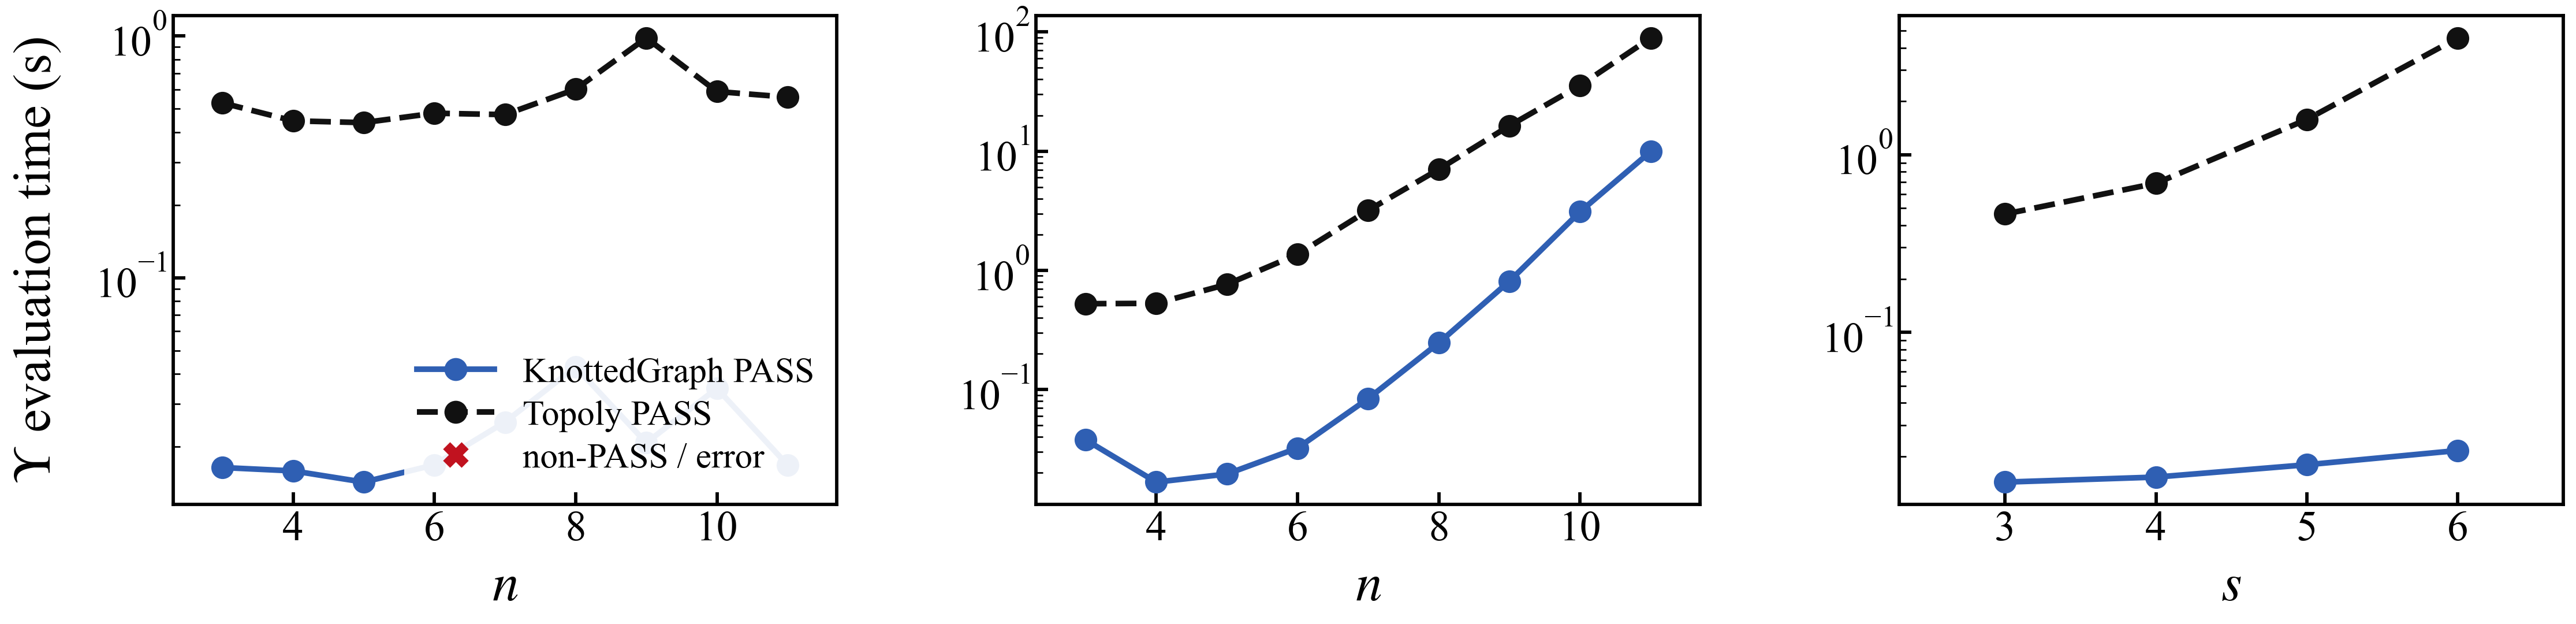

Saved: /Users/hakanakgun/Desktop/Projects/ProfLeeProjects/Knotted_graph_code_paper/LatestGit/User_guide/benchmarks/figures/06_paper_scaling_from_03_csv_scaling_1x3.pdf
Saved: /Users/hakanakgun/Desktop/Projects/ProfLeeProjects/Knotted_graph_code_paper/LatestGit/User_guide/benchmarks/figures/06_paper_scaling_from_03_csv_scaling_1x3.png
Saved grid-ready scaling source: /Users/hakanakgun/Desktop/Projects/ProfLeeProjects/Knotted_graph_code_paper/LatestGit/User_guide/benchmarks/figures/06_paper_scaling_from_03_csv_scaling_1x3_grid_source.pdf
Saved grid-ready scaling source: /Users/hakanakgun/Desktop/Projects/ProfLeeProjects/Knotted_graph_code_paper/LatestGit/User_guide/benchmarks/figures/06_paper_scaling_from_03_csv_scaling_1x3_grid_source.png


In [8]:
PASS_MARKER_SIZE = 135
NONPASS_MARKER_SIZE = 210
PASS_MARKER = "o"
NONPASS_MARKER = "X"
DRAW_SCALING_PANEL_LABELS = False


def result_is_pass(row: dict, framework: str) -> bool:
    """Interpret the CSV verdict columns: only literal PASS is correct."""
    result = str(row.get(f"{framework}_result", "")).strip().upper()
    if result:
        return result == "PASS"
    fallback_columns = (
        ("knottedgraph_vs_published", "knottedgraph_vs_theorem")
        if framework == "knottedgraph"
        else ("topoly_vs_published", "topoly_vs_theorem")
    )
    verdicts = [str(row.get(column, "")).strip().upper() for column in fallback_columns if str(row.get(column, "")).strip()]
    return bool(verdicts) and all(verdict == "PASS" for verdict in verdicts)


def finite_time_rows(frame: list[dict], time_column: str) -> list[dict]:
    return sorted(
        [row for row in frame if finite_positive(row.get(time_column))],
        key=lambda row: (to_int(row.get("size", -1)), row.get("_row_order", -1)),
    )


def style_axis(ax, *, panel_label: str, spec: dict, row_count: int):
    ax.set_yscale("log")
    ax.grid(False)
    ax.set_facecolor("white")
    ax.set_title("")
    for side in ("top", "right", "bottom", "left"):
        ax.spines[side].set_visible(True)
        ax.spines[side].set_color("black")
        ax.spines[side].set_linewidth(AXIS_LINE_WIDTH)
    ax.tick_params(which="major", top=False, right=False, labelsize=TICK_FONT_SIZE, width=AXIS_LINE_WIDTH, length=7, colors="black")
    ax.tick_params(which="minor", top=False, right=False, width=0.9, length=4, colors="black")
    ax.set_xlabel(spec["x_label"], labelpad=8)
    if DRAW_SCALING_PANEL_LABELS and panel_label:
        ax.text(
            -0.125, 1.045, panel_label,
            transform=ax.transAxes,
            fontsize=PANEL_LABEL_FONT_SIZE,
            fontweight="bold",
            fontfamily="serif",
            color="black",
            ha="left",
            va="bottom",
            clip_on=False,
            zorder=20,
        )


def draw_timed_series(ax, rows: list[dict], *, framework: str, time_column: str, color: str, linestyle: str):
    if not rows:
        return
    x = np.array([to_int(row["size"]) for row in rows], dtype=float)
    y = np.array([to_float(row[time_column]) for row in rows], dtype=float)
    ok = np.array([result_is_pass(row, framework) for row in rows], dtype=bool)

    # Draw the scaling trend once, then give each point exactly one correctness marker.
    ax.plot(x, y, color=color, linestyle=linestyle, linewidth=SERIES_LINE_WIDTH, zorder=2)
    if ok.any():
        ax.scatter(
            x[ok], y[ok], marker=PASS_MARKER, s=PASS_MARKER_SIZE,
            facecolors=color, edgecolors=color, linewidths=1.2, zorder=4,
        )
    if (~ok).any():
        ax.scatter(
            x[~ok], y[~ok], marker=NONPASS_MARKER, s=NONPASS_MARKER_SIZE,
            color=ERROR_COLOR, linewidths=1.7, zorder=6,
        )


def draw_family_scaling(ax, spec: dict, frame: list[dict], *, panel_label: str):
    kg = finite_time_rows(frame, "knottedgraph_s")
    tp = finite_time_rows(frame, "topoly_s")
    draw_timed_series(ax, kg, framework="knottedgraph", time_column="knottedgraph_s", color=KG_COLOR, linestyle="-")
    draw_timed_series(ax, tp, framework="topoly", time_column="topoly_s", color=TOPOLY_COLOR, linestyle="--")
    observed = sorted(to_int(row.get("size")) for row in frame)
    if observed:
        ax.set_xlim(min(observed) - 0.7, max(observed) + 0.7)
    style_axis(ax, panel_label=panel_label, spec=spec, row_count=len(frame))


fig, axes = plt.subplots(1, 3, figsize=(21.0, 6.25), constrained_layout=False, facecolor="white")
for index, (ax, spec) in enumerate(zip(axes, FAMILY_SPECS)):
    draw_family_scaling(ax, spec, family_frames[spec["key"]], panel_label=f"({chr(ord('b') + index)})")
for ax in axes[1:]:
    ax.set_ylabel("")
axes[0].set_ylabel(r"$\Upsilon$ evaluation time (s)", labelpad=18)

legend_handles = [
    Line2D([0], [0], color=KG_COLOR, linestyle="-", marker=PASS_MARKER, markersize=12, linewidth=SERIES_LINE_WIDTH, label="KnottedGraph PASS"),
    Line2D([0], [0], color=TOPOLY_COLOR, linestyle="--", marker=PASS_MARKER, markersize=12, linewidth=SERIES_LINE_WIDTH, label="Topoly PASS"),
    Line2D([0], [0], color=ERROR_COLOR, linestyle="None", marker=NONPASS_MARKER, markersize=13, label="non-PASS / error"),
]
axes[0].legend(
    handles=legend_handles,
    loc="lower right",
    bbox_to_anchor=(0.985, 0.035),
    fontsize=LEGEND_FONT_SIZE,
    frameon=True,
    framealpha=0.92,
    facecolor="white",
    edgecolor="none",
    handlelength=2.2,
    borderpad=0.36,
    labelspacing=0.30,
    borderaxespad=0.0,
)
fig.subplots_adjust(left=0.100, right=0.996, top=0.825, bottom=0.210, wspace=0.30)

scaling_png = FIGURE_DIR / f"{SCALING_BASENAME}.png"
scaling_pdf = FIGURE_DIR / f"{SCALING_BASENAME}.pdf"

# Keep the existing standalone performance outputs completely unchanged.
fig.savefig(
    scaling_pdf,
    dpi=PDF_DPI,
    bbox_inches="tight",
    pad_inches=0.08,
    facecolor="white",
    edgecolor="none",
)
fig.savefig(
    scaling_png,
    dpi=PNG_DPI,
    bbox_inches="tight",
    pad_inches=0.08,
    facecolor="white",
    edgecolor="none",
)

# ------------------------------------------------------------------
# Grid-ready performance-row source
# ------------------------------------------------------------------
# The final figure is an exact 3-column grid, so each performance axis must
# sit entirely inside one third.  We only reposition the existing axes for
# this additional raster source; all plotted data, scales, titles, legend,
# fonts, markers, and line styles remain unchanged.
#
# After saving the grid source, the original axes positions are restored, so
# the standalone scaling figure above and the notebook display remain exactly
# as before.
scaling_grid_png = FIGURE_DIR / f"{SCALING_BASENAME}_grid_source.png"
scaling_grid_pdf = FIGURE_DIR / f"{SCALING_BASENAME}_grid_source.pdf"

_original_scaling_positions = [ax.get_position().frozen() for ax in axes]

# Preserve essentially the same plot width/height while keeping every axis,
# title, and label on its own side of the 1/3 and 2/3 separators.
_grid_axis_width = min(
    min(pos.width for pos in _original_scaling_positions),
    0.245,
)

# Give the first cell a little extra left room for its y-axis label.
_grid_x0 = [
    0.078,
    1.0 / 3.0 + (1.0 / 3.0 - _grid_axis_width) / 2.0,
    2.0 / 3.0 + (1.0 / 3.0 - _grid_axis_width) / 2.0,
]

for ax, original_pos, x0 in zip(axes, _original_scaling_positions, _grid_x0):
    ax.set_position(
        [
            x0,
            original_pos.y0,
            _grid_axis_width,
            original_pos.height,
        ]
    )

# Save the COMPLETE canvas (no tight horizontal crop), because exact thirds
# are required by the 3x3 compositor below.
fig.savefig(
    scaling_grid_png,
    dpi=PNG_DPI,
    bbox_inches=None,
    pad_inches=0.0,
    facecolor="white",
    edgecolor="none",
)
fig.savefig(
    scaling_grid_pdf,
    dpi=PDF_DPI,
    bbox_inches=None,
    pad_inches=0.0,
    facecolor="white",
    edgecolor="none",
)

# Restore the user's original performance-panel layout.
for ax, original_pos in zip(axes, _original_scaling_positions):
    ax.set_position(original_pos)

plt.show()
print("Saved:", scaling_pdf)
print("Saved:", scaling_png)
print("Saved grid-ready scaling source:", scaling_grid_pdf)
print("Saved grid-ready scaling source:", scaling_grid_png)


3x3 independent row raster sizes: {'3d_row': (5600, 1440), 'projection_pd_row': (5600, 1440), 'performance_row': (5600, 1314)}


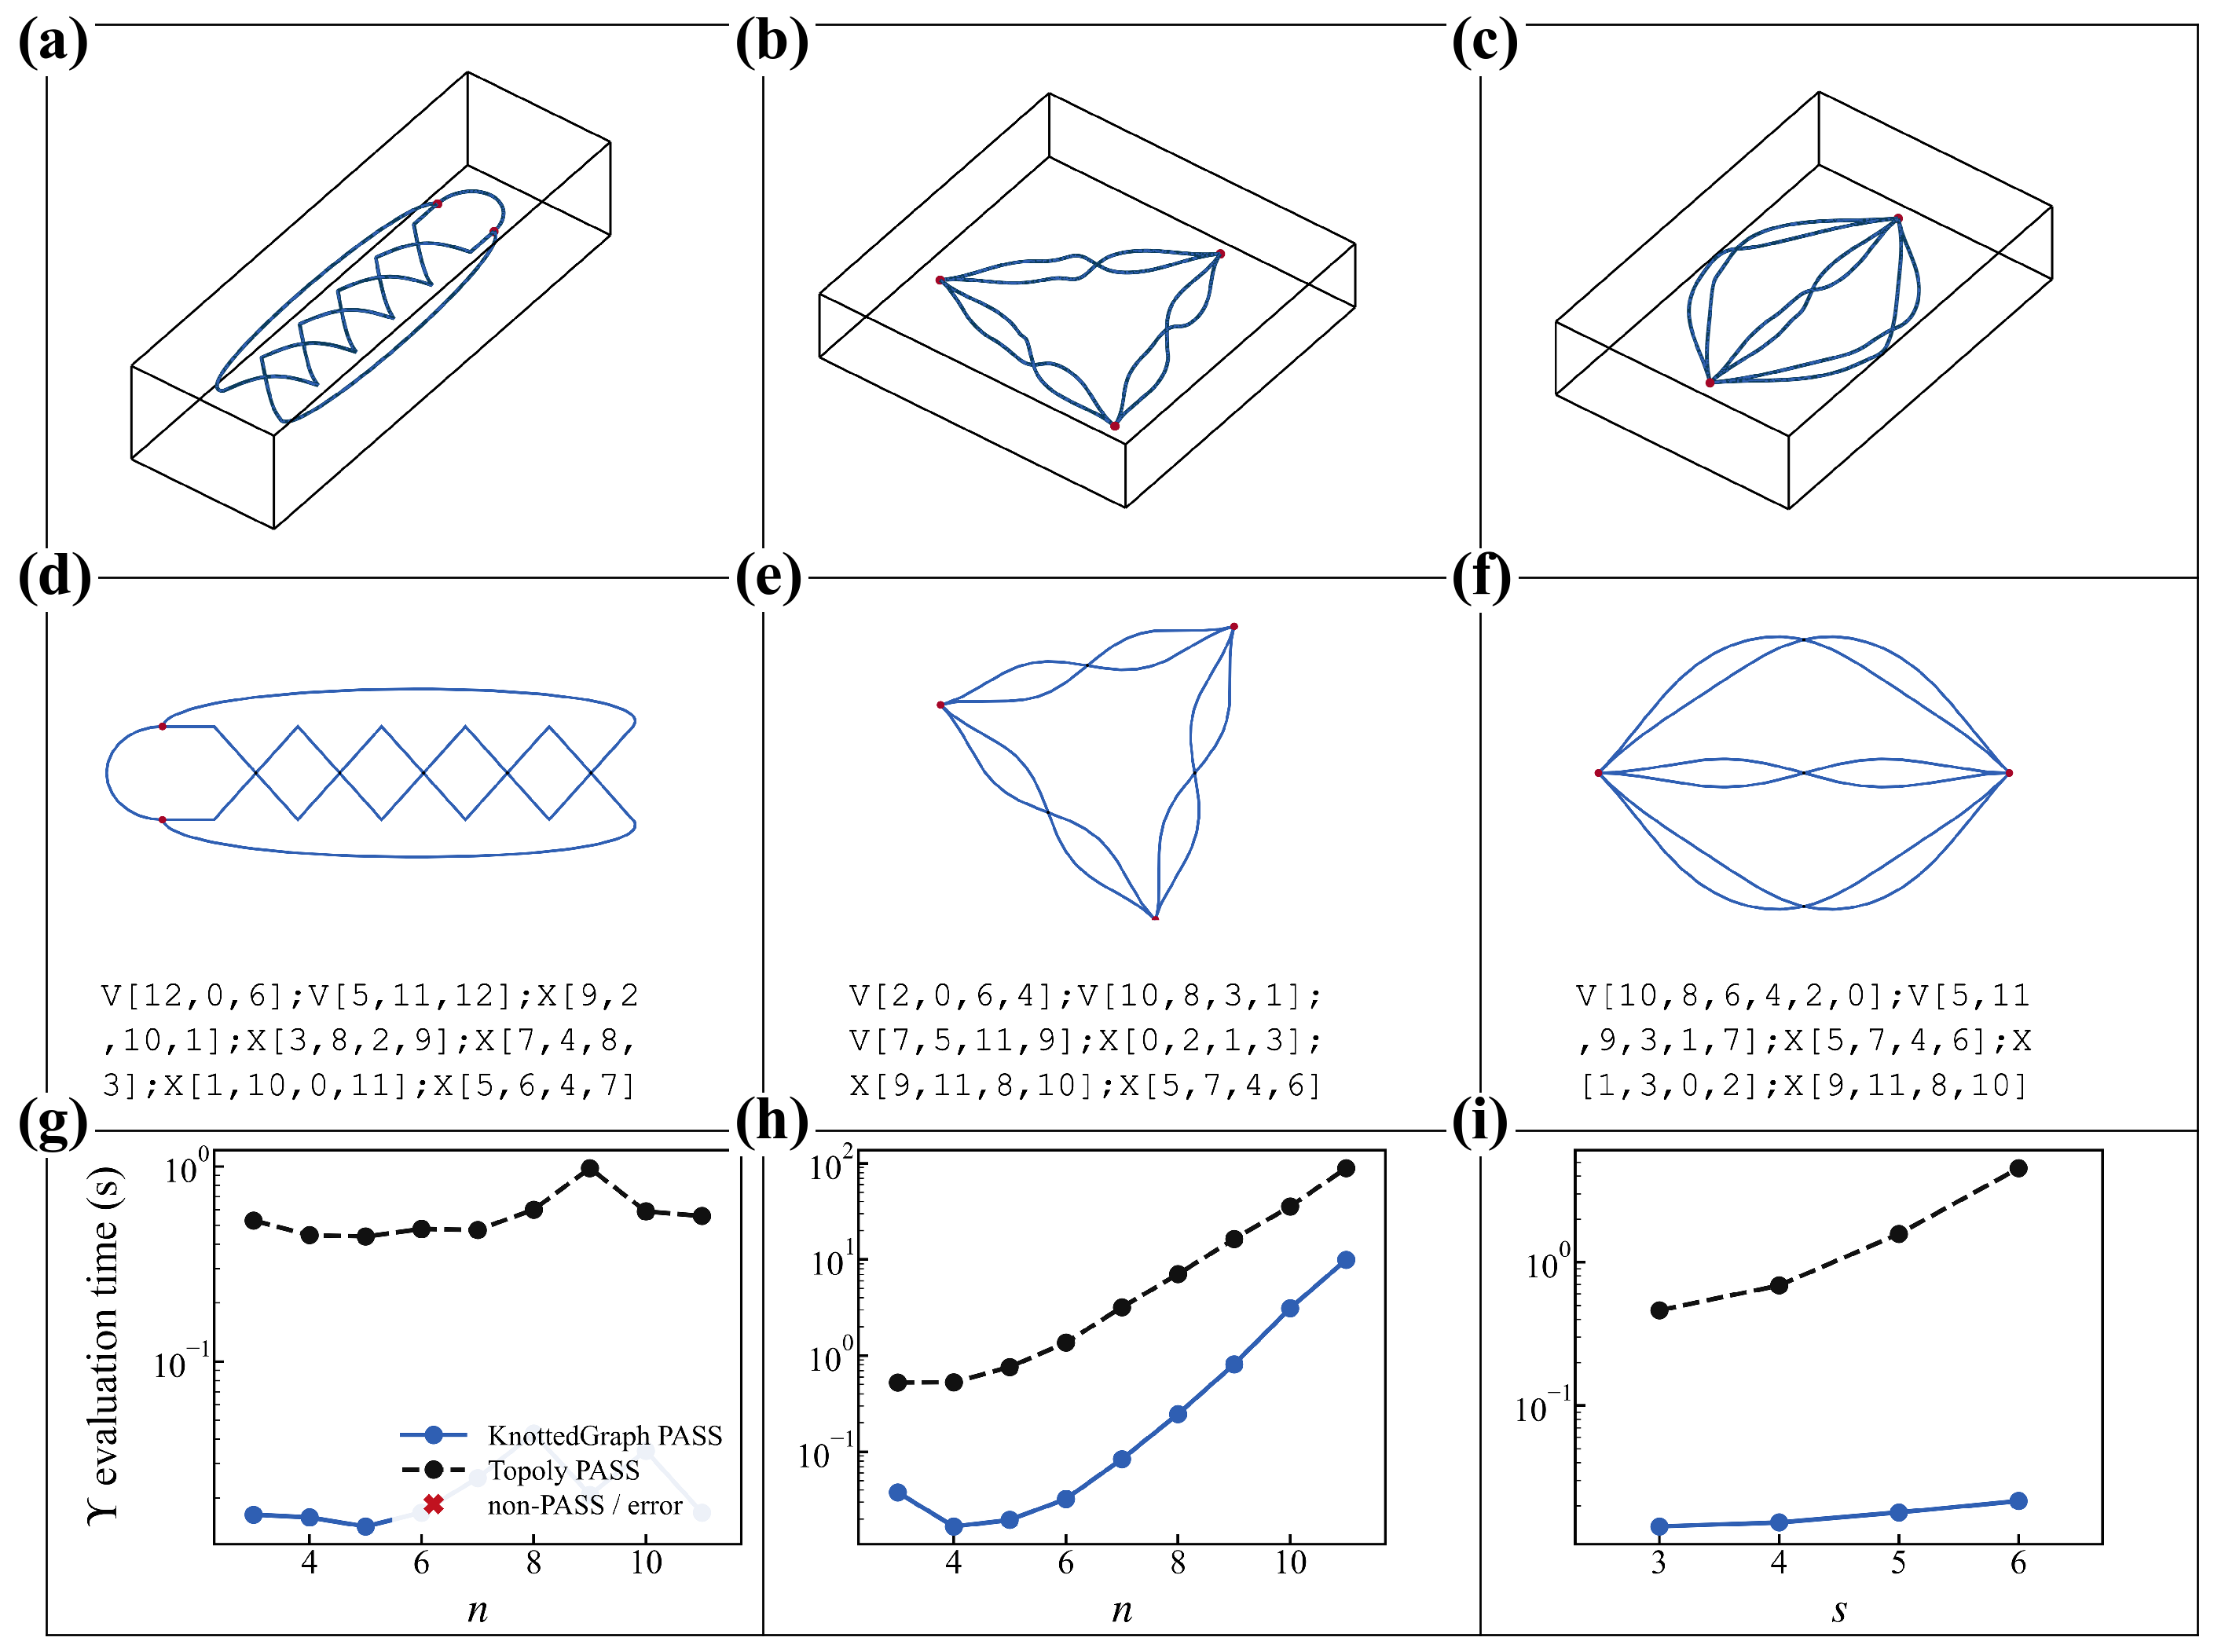

Saved 3x3: /Users/hakanakgun/Desktop/Projects/ProfLeeProjects/Knotted_graph_code_paper/LatestGit/User_guide/benchmarks/figures/06_paper_scaling_from_03_csv_three_row_3x3.pdf
Saved 3x3: /Users/hakanakgun/Desktop/Projects/ProfLeeProjects/Knotted_graph_code_paper/LatestGit/User_guide/benchmarks/figures/06_paper_scaling_from_03_csv_three_row_3x3.png
Saved legacy-compatible: /Users/hakanakgun/Desktop/Projects/ProfLeeProjects/Knotted_graph_code_paper/LatestGit/User_guide/benchmarks/figures/topoly_vs_knottedgraph_two_row_combined.pdf
Saved legacy-compatible: /Users/hakanakgun/Desktop/Projects/ProfLeeProjects/Knotted_graph_code_paper/LatestGit/User_guide/benchmarks/figures/topoly_vs_knottedgraph_two_row_combined.png


In [9]:
def trim_white_margins(
    img,
    *,
    threshold=250,
    pad_px=3,
    trim_horizontal=True,
    trim_vertical=True,
):
    """Trim outer whitespace selectively while preserving 3-column registration."""
    arr = np.asarray(img)
    mask = np.any(arr < threshold, axis=2)

    if not mask.any():
        return img

    ys, xs = np.where(mask)

    if trim_horizontal:
        left = max(int(xs.min()) - pad_px, 0)
        right = min(
            int(xs.max()) + 1 + pad_px,
            img.width,
        )
    else:
        left, right = 0, img.width

    if trim_vertical:
        top = max(int(ys.min()) - pad_px, 0)
        bottom = min(
            int(ys.max()) + 1 + pad_px,
            img.height,
        )
    else:
        top, bottom = 0, img.height

    return img.crop(
        (
            left,
            top,
            right,
            bottom,
        )
    )


def resize_to_width(img, width):
    """Resize without changing aspect ratio."""
    if img.width == width:
        return img

    new_height = round(
        img.height * width / img.width
    )

    return img.resize(
        (width, new_height),
        Image.LANCZOS,
    )


# ============================================================================
# Final 3 x 3 composition
# ============================================================================
#
# IMPORTANT:
# Row 1 and row 2 are NOT crops of the old combined Plotly workflow anymore.
# They are independent source figures:
#
#   final_3d_row_png  -> only 3D embeddings
#   final_pd_row_png  -> only projections + PD code
#
# Therefore a negative ROW1_ROW2_GAP in the old workflow cannot place pieces
# of the 3D graph/box inside the PD row.

img_row_3d = Image.open(
    final_3d_row_png
).convert("RGB")

img_row_pd = Image.open(
    final_pd_row_png
).convert("RGB")

img_row_perf = Image.open(
    scaling_grid_png
).convert("RGB")


# Keep the complete horizontal source widths for ALL rows.
# Exact 1/3 and 2/3 registration would be destroyed by horizontal trimming.
#
# For the dedicated Plotly rows, do not vertically trim either: their internal
# scene/projection domains already provide controlled safety padding, and
# keeping the complete raster guarantees that no box/text stroke can be cut.
img_row_3d = trim_white_margins(
    img_row_3d,
    pad_px=0,
    trim_horizontal=False,
    trim_vertical=False,
)

img_row_pd = trim_white_margins(
    img_row_pd,
    pad_px=0,
    trim_horizontal=False,
    trim_vertical=False,
)

# The performance row is a Matplotlib canvas; only its external vertical
# whitespace may be reduced. Horizontal trimming remains forbidden.
img_row_perf = trim_white_margins(
    img_row_perf,
    pad_px=FINAL_GRID_SCALING_TRIM_PAD_PX,
    trim_horizontal=False,
    trim_vertical=True,
)


# Use the smallest width so no source row is upsampled.
target_row_width = min(
    img_row_3d.width,
    img_row_pd.width,
    img_row_perf.width,
)

img_row_3d = resize_to_width(
    img_row_3d,
    target_row_width,
)
img_row_pd = resize_to_width(
    img_row_pd,
    target_row_width,
)
img_row_perf = resize_to_width(
    img_row_perf,
    target_row_width,
)

print(
    "3x3 independent row raster sizes:",
    {
        "3d_row": img_row_3d.size,
        "projection_pd_row": img_row_pd.size,
        "performance_row": img_row_perf.size,
    },
)


# ------------------------------------------------------------------
# Output paths
# ------------------------------------------------------------------
combined_png = FIGURE_DIR / (
    f"{FIGURE_BASENAME}_three_row_3x3.png"
)
combined_pdf = FIGURE_DIR / (
    f"{FIGURE_BASENAME}_three_row_3x3.pdf"
)

# Keep the previous manuscript-facing names as compatibility outputs.
legacy_png = FIGURE_DIR / (
    "topoly_vs_knottedgraph_two_row_combined.png"
)
legacy_pdf = FIGURE_DIR / (
    "topoly_vs_knottedgraph_two_row_combined.pdf"
)


# ------------------------------------------------------------------
# Grid geometry
# ------------------------------------------------------------------
GRID_LEFT = 0.018
GRID_RIGHT = 0.992
GRID_TOP = 0.972
GRID_BOTTOM = 0.035

PANEL_GRID_ZORDER = 1000

content_width_in = (
    target_row_width / PNG_DPI
)

row_3d_height_in = (
    img_row_3d.height / PNG_DPI
)
row_pd_height_in = (
    img_row_pd.height / PNG_DPI
)
row_perf_height_in = (
    img_row_perf.height / PNG_DPI
)

usable_horizontal_fraction = (
    GRID_RIGHT - GRID_LEFT
)
usable_vertical_fraction = (
    GRID_TOP - GRID_BOTTOM
)

MERGED_FIG_WIDTH = (
    content_width_in
    / usable_horizontal_fraction
)

MERGED_FIG_HEIGHT = (
    row_3d_height_in
    + row_pd_height_in
    + row_perf_height_in
) / usable_vertical_fraction

row_3d_height_frac = (
    row_3d_height_in
    / MERGED_FIG_HEIGHT
)
row_pd_height_frac = (
    row_pd_height_in
    / MERGED_FIG_HEIGHT
)
row_perf_height_frac = (
    row_perf_height_in
    / MERGED_FIG_HEIGHT
)


# Bottom-up row coordinates.
perf_y0 = GRID_BOTTOM
perf_y1 = (
    perf_y0
    + row_perf_height_frac
)

pd_y0 = perf_y1
pd_y1 = (
    pd_y0
    + row_pd_height_frac
)

embedding_y0 = pd_y1
embedding_y1 = (
    embedding_y0
    + row_3d_height_frac
)

assert abs(
    embedding_y1 - GRID_TOP
) < 5e-6, (
    embedding_y1,
    GRID_TOP,
)


# ------------------------------------------------------------------
# Draw source rows
# ------------------------------------------------------------------
fig = plt.figure(
    figsize=(
        MERGED_FIG_WIDTH,
        MERGED_FIG_HEIGHT,
    ),
    facecolor="white",
)

ax_row_3d = fig.add_axes(
    [
        GRID_LEFT,
        embedding_y0,
        usable_horizontal_fraction,
        row_3d_height_frac,
    ]
)

ax_row_pd = fig.add_axes(
    [
        GRID_LEFT,
        pd_y0,
        usable_horizontal_fraction,
        row_pd_height_frac,
    ]
)

ax_row_perf = fig.add_axes(
    [
        GRID_LEFT,
        perf_y0,
        usable_horizontal_fraction,
        row_perf_height_frac,
    ]
)

for ax, img in (
    (ax_row_3d, img_row_3d),
    (ax_row_pd, img_row_pd),
    (ax_row_perf, img_row_perf),
):
    ax.imshow(
        img,
        aspect="auto",
        interpolation="none",
    )
    ax.set_axis_off()


left = GRID_LEFT
right = GRID_RIGHT
bottom = GRID_BOTTOM
top = GRID_TOP


# ------------------------------------------------------------------
# Labels
# ------------------------------------------------------------------
# Row 1: (a), (b), (c) = 3D
# Row 2: (d), (e), (f) = projection + PD code
# Row 3: (g), (h), (i) = performance
column_width_frac = (
    (right - left) / ncols
)

panel_label_x_inset = (
    PANEL_LABEL_X_INSET
    * (right - left)
    + PANEL_LABEL_X_SHIFT
    + FINAL_GRID_PANEL_LABEL_X_SHIFT
)

panel_label_xs = [
    left
    + column_width_frac * k
    + panel_label_x_inset
    for k in range(ncols)
]

row_label_tops = [
    top,
    pd_y1,
    perf_y1,
]

row_labels = [
    ("(a)", "(b)", "(c)"),
    ("(d)", "(e)", "(f)"),
    ("(g)", "(h)", "(i)"),
]

row_label_y_shifts = [
    FINAL_GRID_PANEL_LABEL_Y_SHIFTS["abc"],
    FINAL_GRID_PANEL_LABEL_Y_SHIFTS["def"],
    FINAL_GRID_PANEL_LABEL_Y_SHIFTS["ghi"],
]

for row_top, labels, row_y_shift in zip(
    row_label_tops,
    row_labels,
    row_label_y_shifts,
):
    for x, label in zip(
        panel_label_xs,
        labels,
    ):
        fig.text(
            x,
            row_top
            - FINAL_GRID_LABEL_Y_INSET
            + row_y_shift,
            label,
            fontsize=FINAL_GRID_PANEL_LABEL_FONT_SIZE,
            fontweight=FINAL_GRID_PANEL_LABEL_FONT_WEIGHT,
            fontfamily=FINAL_GRID_PANEL_LABEL_FONT_FAMILY,
            color="black",
            ha="left",
            va="top",
            # Tiny opaque white background so grid/3D-box lines cannot run
            # directly through the (a)...(i) labels.  The padding is deliberately
            # very small and does not alter label position or typography.
            bbox=dict(
                facecolor="white",
                edgecolor="none",
                linewidth=0,
                boxstyle="square,pad=0.08",
            ),
            clip_on=False,
            zorder=1100,
        )


# ------------------------------------------------------------------
# True 3 x 3 separators
# ------------------------------------------------------------------
for k in range(ncols + 1):
    x = (
        left
        + (right - left)
        * (k / ncols)
    )

    fig.add_artist(
        Line2D(
            [x, x],
            [bottom, top],
            transform=fig.transFigure,
            color=FINAL_GRID_COLOR,
            linewidth=FINAL_GRID_LINEWIDTH,
            zorder=PANEL_GRID_ZORDER,
            clip_on=False,
        )
    )

for y in (
    bottom,
    perf_y1,
    pd_y1,
    top,
):
    fig.add_artist(
        Line2D(
            [left, right],
            [y, y],
            transform=fig.transFigure,
            color=FINAL_GRID_COLOR,
            linewidth=FINAL_GRID_LINEWIDTH,
            zorder=PANEL_GRID_ZORDER,
            clip_on=False,
        )
    )


# ------------------------------------------------------------------
# Save
# ------------------------------------------------------------------
fig.savefig(
    combined_pdf,
    dpi=PDF_DPI,
    bbox_inches="tight",
    pad_inches=0.01,
    facecolor="white",
    edgecolor="none",
)

fig.savefig(
    combined_png,
    dpi=PNG_DPI,
    bbox_inches="tight",
    pad_inches=0.01,
    facecolor="white",
    edgecolor="none",
)

fig.savefig(
    legacy_pdf,
    dpi=PDF_DPI,
    bbox_inches="tight",
    pad_inches=0.01,
    facecolor="white",
    edgecolor="none",
)

fig.savefig(
    legacy_png,
    dpi=PNG_DPI,
    bbox_inches="tight",
    pad_inches=0.01,
    facecolor="white",
    edgecolor="none",
)

plt.show()

print("Saved 3x3:", combined_pdf)
print("Saved 3x3:", combined_png)
print("Saved legacy-compatible:", legacy_pdf)
print("Saved legacy-compatible:", legacy_png)
